# Single-cell RNA-seq

- [Single-cell RNA-seq](#single-cell-rna-seq)
  - [Introduction and data source <a name="intro"></a>](#introduction-and-data-source-<a-name="intro"></a>)
  - [Data analysis <a name="data"></a>](#data-analysis-<a-name="data"></a>)
    - [Data preprocessing <a name="subdata1"></a>](#data-preprocessing-<a-name="subdata1"></a>)
    - [Quality Control <a name="subdata2"></a>](#quality-control-<a-name="subdata2"></a>)
      - [Detecting doublets <a name="subsub1"></a>](#detecting-doublets-<a-name="subsub1"></a>)
      - [Filtering broken cells and cells that do not contain enough genes <a name="subsub2"></a>](#filtering-broken-cells-and-cells-that-do-not-contain-enough-genes-<a-name="subsub2"></a>)
    - [Normalization <a name="normalize"></a>](#normalization-<a-name="normalize"></a>)
    - [Variable genes and PCA for dimensionality reduction <a name="PCA"></a>](#variable-genes-and-pca-for-dimensionality-reduction-<a-name="pca"></a>)
    - [Embeddings](#embeddings)
      - [Clustering <a name="batch"></a>](#clustering-<a-name="batch"></a>)
      - [Removing doublet clusters](#removing-doublet-clusters)
      - [Marker genes <a name="mark"></a>](#marker-genes-<a-name="mark"></a>)
      - [Cell type annotation <a name="annotation"></a>](#cell-type-annotation-<a-name="annotation"></a>)
        - [Adding metadata](#adding-metadata)
      - [predict cell linage](#predict-cell-linage)
  - [Functional Analysis](#functional-analysis)
    - [Use the entire ranking to determine the "leading edge"](#use-the-entire-ranking-to-determine-the-"leading-edge")
      - [GORilla/GO Enrichment](#gorilla/go-enrichment)
    - [Motif discovery](#motif-discovery)
  - [Conclusion](#conclusion)


## Introduction and data source <a name="intro"></a>

The dataset is retrieved from paper: ***Single-cell RNA-seq reveal lineage formation and X-chromosome dosage compensation in human preimplantation embryos*** ([Sophie Petropoulos et al 2016](https://www.cell.com/cell/fulltext/S0092-8674(16)30280-X?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS009286741630280X%3Fshowall%3Dtrue#app-2).  
Single-cell RNA-seq of 1,529 cells obtained from 88 human preimplantation embryos ranging from **embryonic day 3 to 7**.Dataset is taken from ArrayExpress database with accession number [E-MTAB-3929](https://www.ebi.ac.uk/biostudies/arrayexpress/studies/E-MTAB-3929).

Preimplantation development is the first seven days after fertilisation. In Vitro fertilization IVF technique, the embryo is cultured and monitored in the lab. In the fist several days, embryos undergo a series of mitotic cell divisions. On or around day 4, the embryo compacts, resulting in the formation of a morula. It consists of cells in a compact cluster contained within the zona pellucida. The blastocyst, which forms on day 5, is a fluid-filled structure composed of an inner cell mass (white arrowhead) and trophectoderm (gray arrowhead). On day 6, the blastocyst ‘hatches’ from the zona pellucida. Healthy blastocyst after preimplantation genetic testing for aneuploidy (PGT-A) can be transferred into the uterine wall for further development.
During the blastocyst stage, the zygote undergoes cellular division and establishes **the first three distinct cell types of the mature blastocyst: trophectoderm (TE), primitive endoderm (PE), and epiblast (EPI)** 
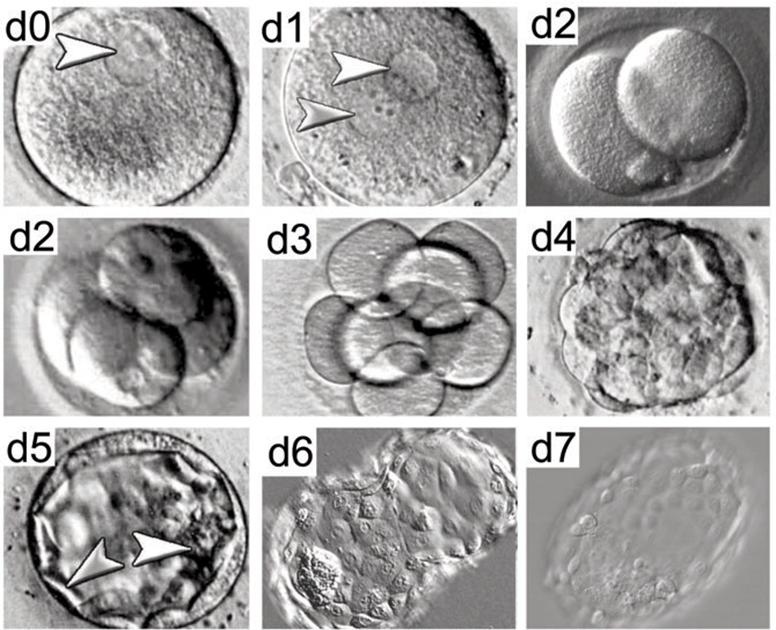

## Data analysis <a name="data"></a>
### Data preprocessing <a name="subdata1"></a>
Data from the count matrices are parsed and plotted to see the top of highest expression genes that take the most percentage over total count of each sample. It can be seen in cell 6 that all samples contain MALAT1 as the highest expressed gene. The followed series of high-expressed genes are quite different between NHS samples (first 2 plots) and AD samples (other 3 plots).

In [1]:
#!mkdir -p ~/.local/share/jupyter/kernels/cbd_bioinf_v4
#!cp /mnt/storage/nhecker/kernels/cbd_bioinf_v4/kernel.json ~/.local/share/jupyter/kernels/cbd_bioinf_v4/

In [2]:
import os
import scanpy as sc
import pandas as pd

outdir = "/mnt/storage/" + os.environ['USER'] + "/jupyternotebooks/Transcriptome/Output"
os.makedirs(outdir, exist_ok=True)

In [3]:
path_data= "/mnt/storage/" + os.environ['USER'] + "/jupyternotebooks/Transcriptome/E-MTAB-3929"
os.listdir(path_data)

['ercc.rpkm.txt',
 'ercc.counts.txt',
 'counts_transposed.txt',
 'counts.txt',
 'rpkm.txt']

The counts.txt file contains raw gene counts with rows representing cell indices and columns representing gene names; we need to transpose it and save the result as counts_transposed.txt in the same directory.

In [4]:
counts_file = os.path.join(path_data, "counts.txt")
counts_data = pd.read_csv(counts_file, sep="\t", index_col=0) 

# Transpose the dataframe
transposed_data = counts_data.transpose()

# Save the transposed data back to a file
transposed_file = os.path.join(path_data, "counts_transposed.txt")
transposed_data.to_csv(transposed_file, sep="\t")

print(f"Transposed file saved to: {path_data}")

Transposed file saved to: /mnt/storage/r0880433/jupyternotebooks/Transcriptome/E-MTAB-3929


In [5]:
adata = sc.read_text(path_data + "/counts_transposed.txt")
print(adata)
print(adata.var_names)
print(adata.obs_names)
print(adata.X)
print(adata.X.shape)

AnnData object with n_obs × n_vars = 1529 × 26178
Index(['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1', 'A2ML1', 'A2MP1',
       'A3GALT2', 'A4GALT', 'A4GNT',
       ...
       'ZWILCH', 'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX',
       'ZZEF1', 'ZZZ3'],
      dtype='object', length=26178)
Index(['E5.5.101', 'E5.5.100', 'E6.2.114', 'E6.2.104', 'E6.2.107', 'E6.2.116',
       'E7.2.138', 'E6.2.118', 'E6.2.105', 'E7.2.144',
       ...
       'E3.50.3415', 'E3.51.3421', 'E3.53.3437', 'E3.51.3423', 'E3.52.3429',
       'E3.49.3407', 'E3.51.3426', 'E3.47.3391', 'E3.52.3431', 'E3.53.3438'],
      dtype='object', length=1529)
[[  0.   0.   0. ...  17.   0.  12.]
 [  0.   0.   0. ...  17.   1.   7.]
 [  0.   0.   0. ...   9.  70. 110.]
 ...
 [473.   7.  40. ...  14.   0. 986.]
 [104.   0.  66. ...   4. 136. 318.]
 [116.   0.  34. ... 160. 144.   0.]]
(1529, 26178)


Embryonic cells are stored in .obs_names. 
First number represents day of embryonic development(day3-day7). Second number means different embyonic samples. Third number means cell index within one embryonic sample.***For example, E6.2.114 refers to a cell from the sixth embryonic day (Day 6), specifically from the second embryonic sample collected on that day, and it is the 114th cell within that sample.***

The gene expression count matrix is stored in .X

The gene names are stored in .var


In [6]:
adata.var_names_make_unique()
adata.obs['day_id'] = adata.obs_names.str.split('.').str[0]  # Extract the part before the first dot
adata.obs['sample_id'] = adata.obs_names.str.rsplit('.', n=1).str[0] # Extract the part before the last dot
print(adata.obs[['day_id', 'sample_id']].head())

         day_id sample_id
E5.5.101     E5      E5.5
E5.5.100     E5      E5.5
E6.2.114     E6      E6.2
E6.2.104     E6      E6.2
E6.2.107     E6      E6.2


In [7]:
# Count occurrences of each combination of day_id
counts = adata.obs.groupby(['day_id']).size().reset_index(name='counts')
print(counts)
# Count occurrences of each combination of day_id and sample_id
counts = adata.obs.groupby(['day_id', 'sample_id']).size().reset_index(name='counts')
print(counts)


  day_id  counts
0     E3      81
1     E4     190
2     E5     377
3     E6     415
4     E7     466
   day_id sample_id  counts
0      E3      E3.1       5
1      E3      E3.2       8
2      E3      E3.3       5
3      E3      E3.4       3
4      E3     E3.45       8
..    ...       ...     ...
84     E7      E7.5      10
85     E7      E7.6      27
86     E7      E7.7      21
87     E7      E7.8      31
88     E7      E7.9      39

[89 rows x 3 columns]


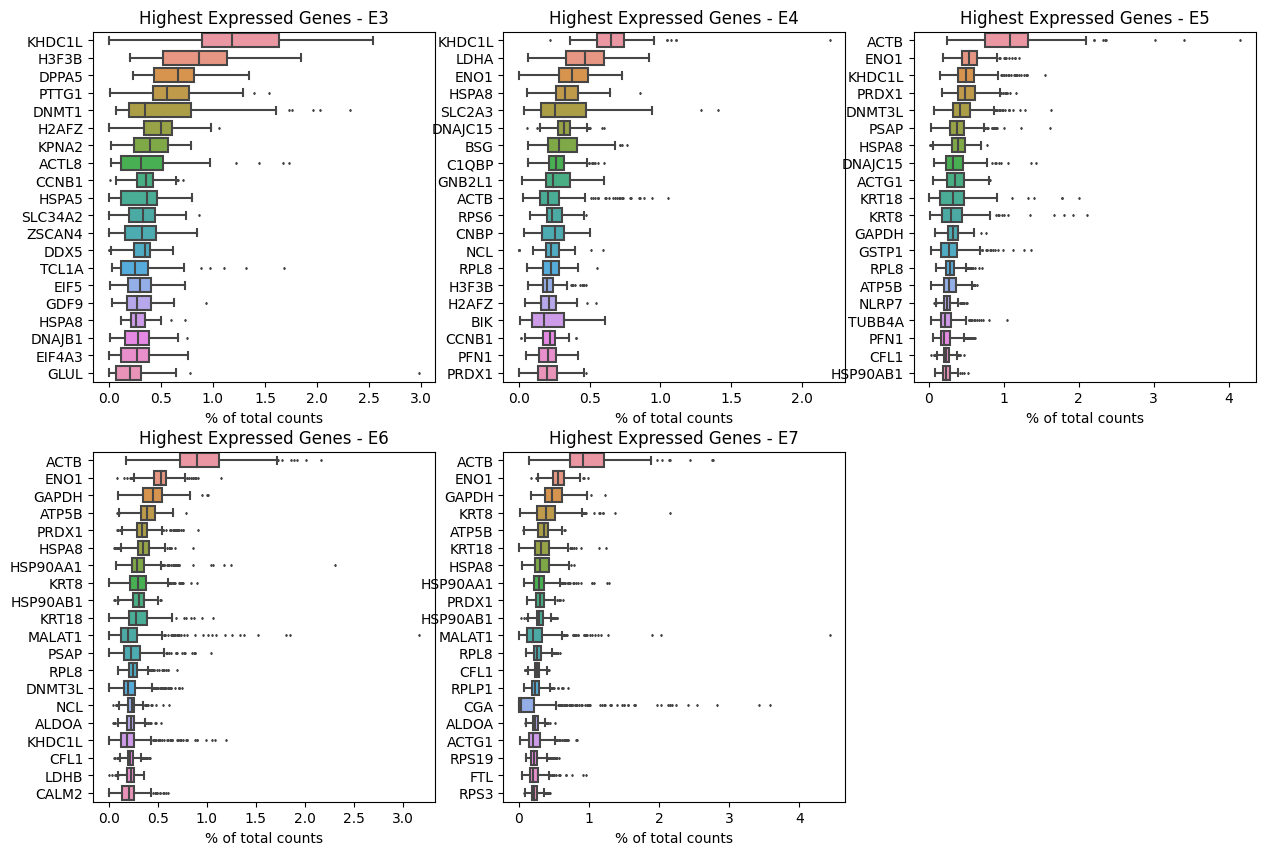

In [8]:
import matplotlib.pyplot as plt
embryonic_days = sorted(adata.obs['day_id'].unique())  # List of unique embryonic days (E3 to E7)

# Create a 2x3 layout (adjusting for the number of plots)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 rows, 3 columns, adjust figure size

# Iterate through the embryonic days
for i, day in enumerate(embryonic_days[:]):  
    ax = axes[i // 3, i % 3]  # Map each plot to the correct subplot

    # Subset the AnnData object for the specific embryonic day and make a copy
    adata_day = adata[adata.obs['day_id'] == day].copy()
    
    # Create the highest expressed genes plot on a specific axis
    sc.pl.highest_expr_genes(adata_day, n_top=20, ax=ax, show=False)
    ax.set_title(f"Highest Expressed Genes - {day}")

# Remove any unused subplot axes
for j in range(len(embryonic_days), 6):
    fig.delaxes(axes[j // 3, j % 3])


### Quality Control <a name="subdata2"></a>
#### Detecting doublets <a name="subsub1"></a>
Scrublet is a popular tool for detecting doublets in single-cell RNA-seq data. It works by simulating artificial doublets from the dataset and comparing their characteristics to the observed cells to identify likely doublets. 

In [9]:
import scrublet as scr
scrub = scr.Scrublet(adata.X, expected_doublet_rate=0.06)
doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts=2, 
                                                          min_cells=3, 
                                                          min_gene_variability_pctl=85, 
                                                          n_prin_comps=30)

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.43
Detected doublet rate = 0.1%
Estimated detectable doublet fraction = 12.2%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 0.5%
Elapsed time: 3.7 seconds


2024-12-30 22:42:29.790494: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/lib/R/lib:/usr/local/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/java-11-openjdk-amd64/lib/server:/.singularity.d/libs
2024-12-30 22:42:29.790521: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


(<Figure size 800x400 with 3 Axes>,
 array([<AxesSubplot:title={'center':'Predicted doublets'}, xlabel='UMAP 1', ylabel='UMAP 2'>,
        <AxesSubplot:title={'center':'Doublet score'}, xlabel='UMAP 1', ylabel='UMAP 2'>],
       dtype=object))

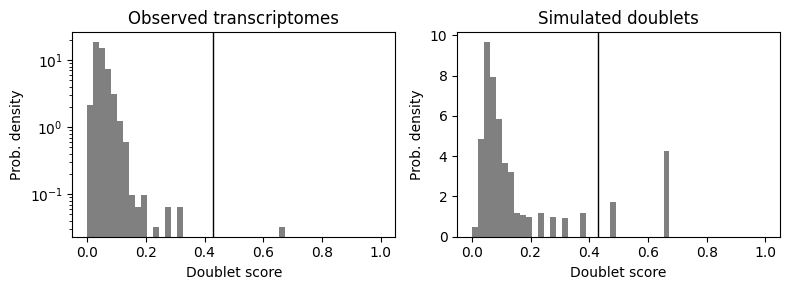

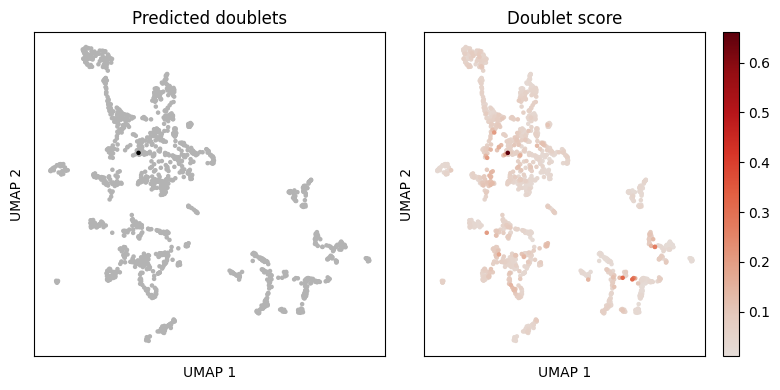

In [10]:
scrub.plot_histogram()
scrub.set_embedding('UMAP', scr.get_umap(scrub.manifold_obs_, 10, min_dist=0.3))
scrub.plot_embedding('UMAP', order_points=True)

To call doublets, a threshold is specified based on simulated doublets. The right histogram is showing simulated doublets and should be bimodal. In the right histogram, the first mode correponds to simulated doublets generated from cells with the roughly same transcriptome. The second mode corresponds to simulated doublets generated from combining distinct transcriptomes. Scrublet cannot detect doublets if they are from cells with similar transcriptomes but they do not severly impact most analysis. The threshold to call doublets is automatically determined and should seperated the two modes at the lowest value. In case the automatic threshold does not seperate the modes well, it can be manully specified. In this example, the automatic threshold looks good.

In [11]:
adata.obs['predicted_doublets'] = predicted_doublets
adata.obs['doublet_scores'] = doublet_scores

In [12]:
adata.obs

,day_id,sample_id,predicted_doublets,doublet_scores
E5.5.101,E5,E5.5,False,0.054845
E5.5.100,E5,E5.5,False,0.051338
E6.2.114,E6,E6.2,False,0.025610
E6.2.104,E6,E6.2,False,0.062812
E6.2.107,E6,E6.2,False,0.030928
...,...,...,...,...
E3.49.3407,E3,E3.49,False,0.030928
E3.51.3426,E3,E3.51,False,0.021109
E3.47.3391,E3,E3.47,False,0.037308
E3.52.3431,E3,E3.52,False,0.030928


our data set is very clean, almost none doublets. However, I still made an analysis to make this pipeline more universal and educative.

#### Filtering broken cells and cells that do not contain enough genes <a name="subsub2"></a>
To remove barcodes that correspond to broken or no cells, we can filter cells by a minimum number of genes. For scRNAseq a minum of `200` genes is a reasonable threshold. Similarly, genes that are not or barely expressed in any  cells are not useful for the analysis.

In [13]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [14]:
adata.var

,n_cells
A1BG,571
A1BG-AS1,194
A1CF,151
A2M,133
A2M-AS1,57
...,...
ZYG11A,1316
ZYG11B,1137
ZYX,1479
ZZEF1,1292


Broken or dying cells can also be detected by a high amount of mitochondrial genes. Mitochondrial mouse genes names start with `mt-` and human with `MT-`. We can specify a flag in `.var` entries for mitochondrial genes.Similarly, we can find ribosomal genes using `Mrps`/`Mrpl` (`RPS`/`RPL` in human) and hemoglobin genes using `Hb` (`HB`). Most ribosomal RNA is not captured in the majority of scRNA-seq protocols since they often rely on on the polyadynelated (polyA) tail of mRNAs for capture. High amounts of ribosomal RNA can be an indicator of low sample quality. To point out, our data did not contain Mitochondrial genes but this step just be kept here.

In [15]:
adata.var['mt'] = adata.var_names.str.startswith('MT-') 
adata.var["ribo"] = adata.var_names.str.startswith(("Mrps", "Mrpl"))
adata.var["hb"] = adata.var_names.str.contains("^Hb[^(p)]")

In [16]:
adata.var

,n_cells,mt,ribo,hb
A1BG,571,False,False,False
A1BG-AS1,194,False,False,False
A1CF,151,False,False,False
A2M,133,False,False,False
A2M-AS1,57,False,False,False
...,...,...,...,...
ZYG11A,1316,False,False,False
ZYG11B,1137,False,False,False
ZYX,1479,False,False,False
ZZEF1,1292,False,False,False


In [17]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo', 'hb'], percent_top=None, log1p=False, inplace=True)

This flag for mitochondrial genes can then be used to compute the percentage of mitochdondrial genes per cell when given as parameter to `calculate_qc_metrics`. `calculate_qc_metrics` will also compute the number of genes and total counts per cell.

`calculate_qc_metrics` computes both metrics for each gene and for each cell

In [18]:
adata.var

,n_cells,mt,ribo,hb,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
A1BG,571,False,False,False,571,32.089600,62.655330,49065.0
A1BG-AS1,194,False,False,False,194,1.126880,87.311969,1723.0
A1CF,151,False,False,False,151,2.355788,90.124264,3602.0
A2M,133,False,False,False,133,1.567691,91.301504,2397.0
A2M-AS1,57,False,False,False,57,0.431001,96.272073,659.0
...,...,...,...,...,...,...,...,...
ZYG11A,1316,False,False,False,1316,107.223679,13.930674,163945.0
ZYG11B,1137,False,False,False,1137,46.550034,25.637672,71175.0
ZYX,1479,False,False,False,1479,251.349243,3.270111,384313.0
ZZEF1,1292,False,False,False,1292,77.043167,15.500327,117799.0


In [19]:
adata.obs

,day_id,sample_id,predicted_doublets,doublet_scores,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb
E5.5.101,E5,E5.5,False,0.054845,8868,8868,380054.0,0.0,0.0,0.0,0.0,0.0,0.0
E5.5.100,E5,E5.5,False,0.051338,9376,9376,380586.0,0.0,0.0,0.0,0.0,0.0,0.0
E6.2.114,E6,E6.2,False,0.025610,7301,7301,341762.0,0.0,0.0,0.0,0.0,0.0,0.0
E6.2.104,E6,E6.2,False,0.062812,8117,8117,111158.0,0.0,0.0,0.0,0.0,0.0,0.0
E6.2.107,E6,E6.2,False,0.030928,6506,6506,148767.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
E3.49.3407,E3,E3.49,False,0.030928,9509,9509,3191632.0,0.0,0.0,0.0,0.0,0.0,0.0
E3.51.3426,E3,E3.51,False,0.021109,10550,10548,6420873.0,0.0,0.0,0.0,0.0,0.0,0.0
E3.47.3391,E3,E3.47,False,0.037308,8965,8965,2673941.0,0.0,0.0,0.0,0.0,0.0,0.0
E3.52.3431,E3,E3.52,False,0.030928,9683,9683,3380835.0,0.0,0.0,0.0,0.0,0.0,0.0


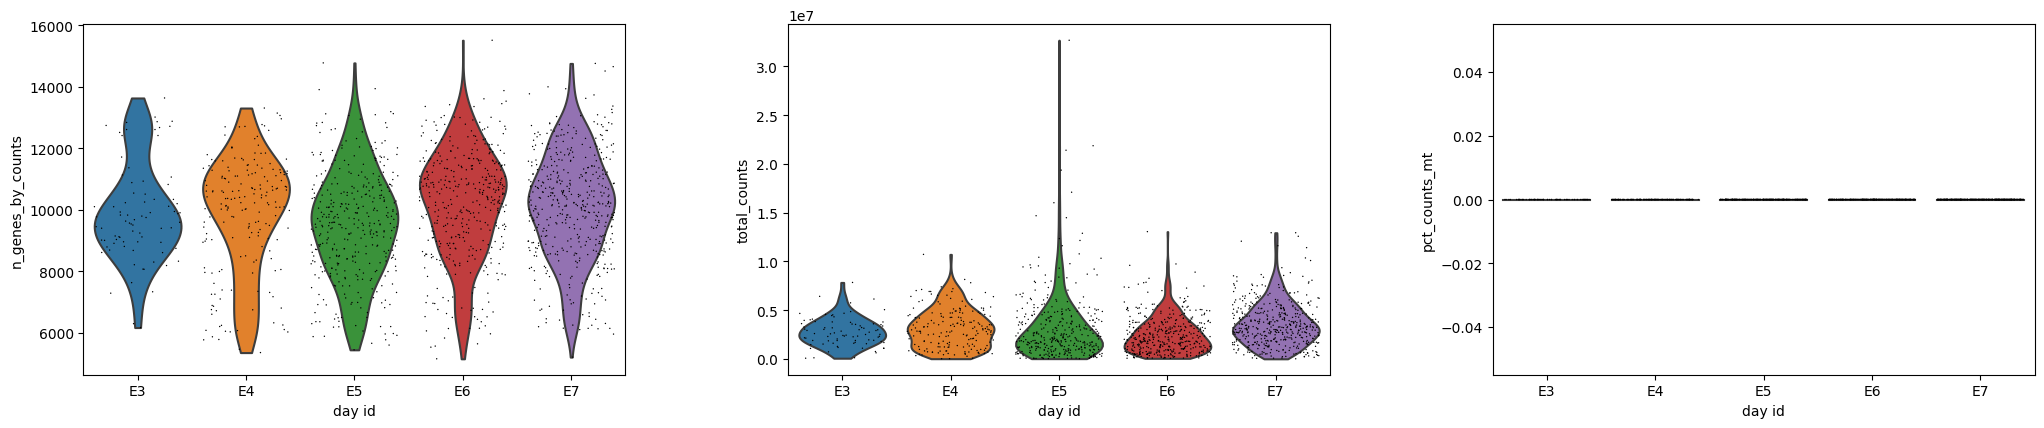

In [20]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, groupby='day_id')

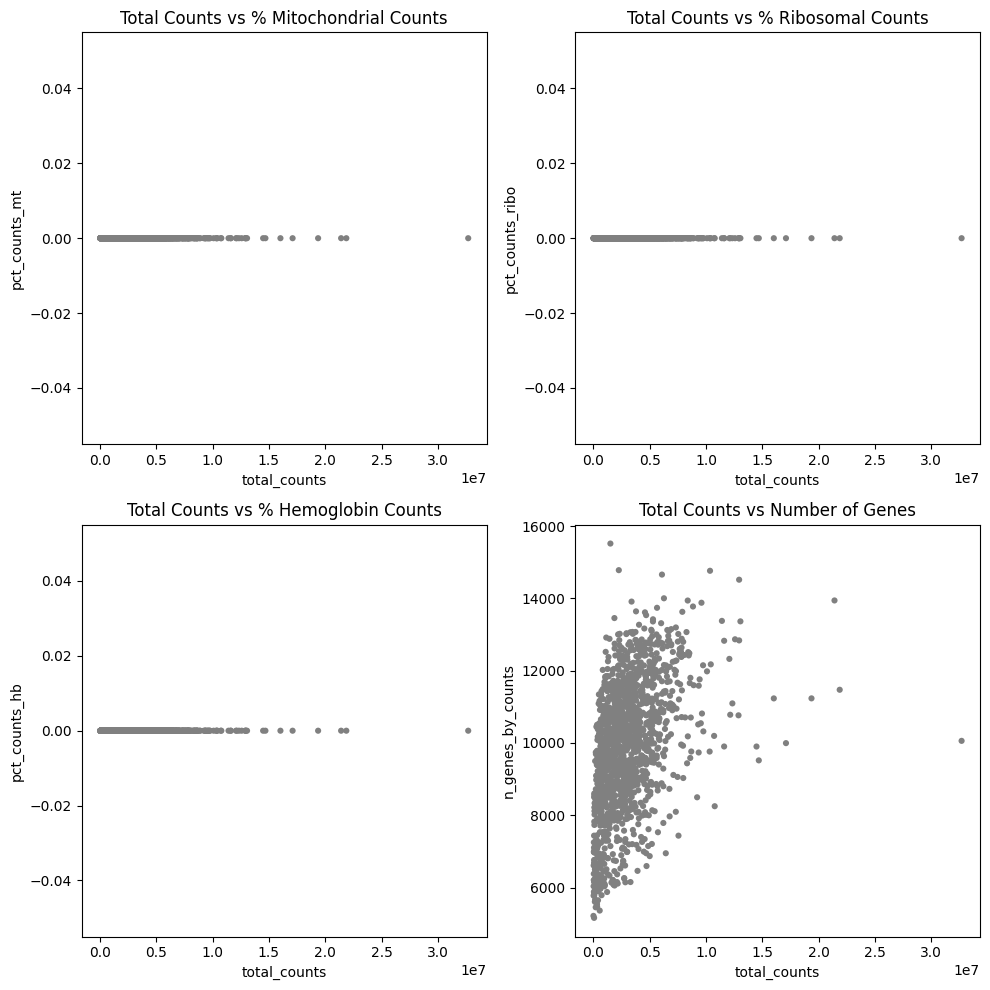

In [21]:
# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Plot each scatter plot in its respective subplot
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', ax=axes[0, 0], show=False)
sc.pl.scatter(adata, x='total_counts', y='pct_counts_ribo', ax=axes[0, 1], show=False)
sc.pl.scatter(adata, x='total_counts', y='pct_counts_hb', ax=axes[1, 0], show=False)
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', ax=axes[1, 1], show=False)

# Add titles to each subplot
axes[0, 0].set_title("Total Counts vs % Mitochondrial Counts")
axes[0, 1].set_title("Total Counts vs % Ribosomal Counts")
axes[1, 0].set_title("Total Counts vs % Hemoglobin Counts")
axes[1, 1].set_title("Total Counts vs Number of Genes")

# Adjust layout
plt.tight_layout()
plt.show()


To point out, our data does not contain Mitochondrial genes and ribosome genes expressions but this step just be kept here.

In [22]:
adata = adata[adata.obs.n_genes_by_counts < 14000, :].copy()
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()
adata = adata[adata.obs.pct_counts_ribo < 5, :].copy()
adata = adata[adata.obs.pct_counts_hb < 5, :].copy()

In [23]:
adata

AnnData object with n_obs × n_vars = 1523 × 23633
    obs: 'day_id', 'sample_id', 'predicted_doublets', 'doublet_scores', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'day_id_colors'

Saving and loading anndata. use the `.write` function.and use `sc.read`to load it

In [24]:
outf = outdir + '/adata_raw_filtered.h5ad'
adata.write(outf)
print(outf)

/mnt/storage/r0880433/jupyternotebooks/Transcriptome/Output/adata_raw_filtered.h5ad


In [25]:
outf = outdir + '/adata_raw_filtered.h5ad'
adata = sc.read(outf)
adata

AnnData object with n_obs × n_vars = 1523 × 23633
    obs: 'day_id', 'sample_id', 'predicted_doublets', 'doublet_scores', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'day_id_colors'

### Normalization <a name="normalize"></a>

Normalizing each cell to a total of 10,000 counts

In [26]:
adata.X #adata.X is already dense

array([[  0.,   0.,   0., ...,  17.,   0.,  12.],
       [  0.,   0.,   0., ...,  17.,   1.,   7.],
       [  0.,   0.,   0., ...,   9.,  70., 110.],
       ...,
       [473.,   7.,  40., ...,  14.,   0., 986.],
       [104.,   0.,  66., ...,   4., 136., 318.],
       [116.,   0.,  34., ..., 160., 144.,   0.]], dtype=float32)

In [27]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [28]:
adata.X

array([[0.        , 0.        , 0.        , ..., 0.3697031 , 0.        ,
        0.27440274],
       [0.        , 0.        , 0.        , ..., 0.36927098, 0.02593601,
        0.16883677],
       [0.        , 0.        , 0.        , ..., 0.23375992, 1.1145542 ,
        1.4395066 ],
       ...,
       [1.0184591 , 0.02584179, 0.13940702, ..., 0.05103258, 0.        ,
        1.5448868 ],
       [0.26820588, 0.        , 0.17832863, ..., 0.01176195, 0.33809057,
        0.66299516],
       [0.43351337, 0.        , 0.14760748, ..., 0.5587626 , 0.51501095,
        0.        ]], dtype=float32)

### Variable genes and PCA for dimensionality reduction <a name="PCA"></a>
In order to compute embeddings and clusterings of our data, we first perform principal component analysis (PCA) for dimensionality reduction. A PCA is often more informative when the data set is limited to variable genes. `highly_variable_genes` offers different `flavors` for identifying highly variable genes; here we are using the default `seurat` style. see https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.highly_variable_genes.html for more details. 

In [29]:
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000, inplace=True)

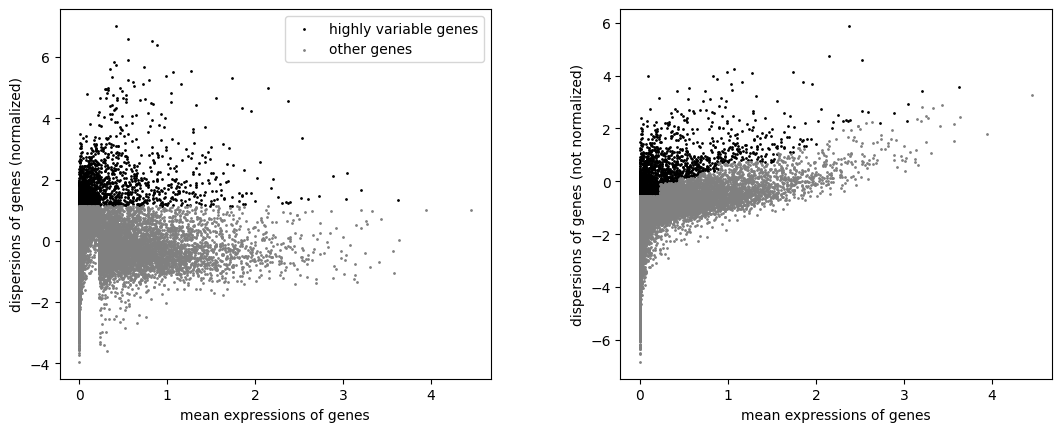

In [30]:
sc.pl.highly_variable_genes(adata)

In [31]:
sc.pp.scale(adata, max_value=10) #log-normalizing data it should be scaled before computing a PCA

For computing the PCA, we specify that we are limiting it to highly variable genes and give the number of PCs to be computed 

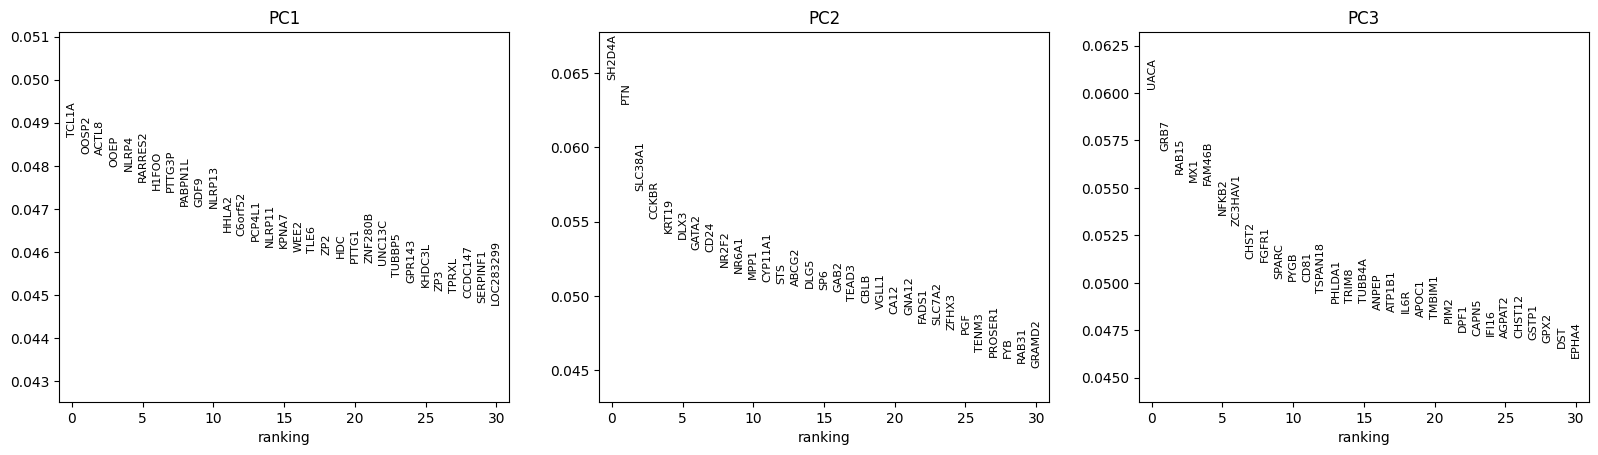

In [32]:
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)
sc.pl.pca_loadings(adata, include_lowest=False)

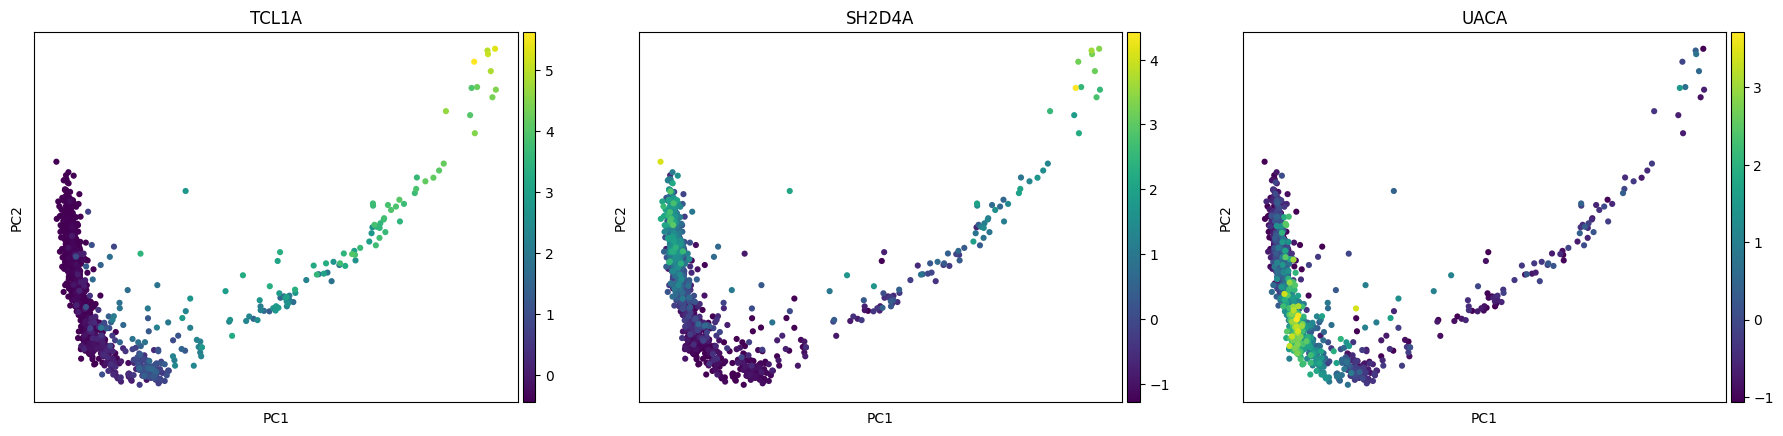

In [33]:
sc.pl.pca(adata, color=['TCL1A', 'SH2D4A',"UACA"])

For downstream steps such as computing embeddings and clusterings, we should limit the number of PCs. Using an elbow plot we can determine the PCs that show a high contribution to variance in our data. The first 40 PCs look like a reasonable choice.

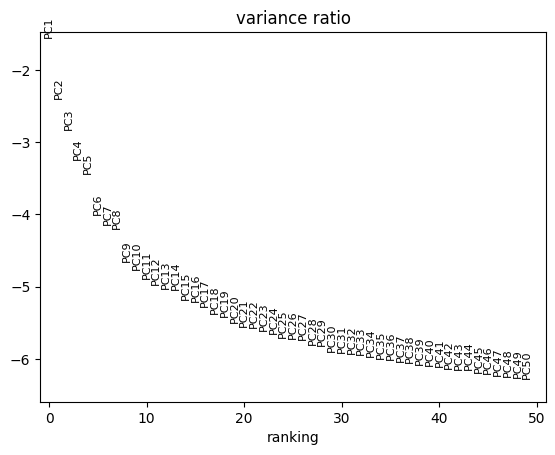

In [34]:
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

### Embeddings
To visualize single cell data in two dimensions, UMAP and tSNE are very useful embeddings. A UMAP uses a neighborhood graph that is computed based on PCs. This neighborhood graph will also be used for Leiden clustering.

In [35]:
sc.pp.neighbors(adata, n_pcs=40)

In [36]:
sc.tl.umap(adata)

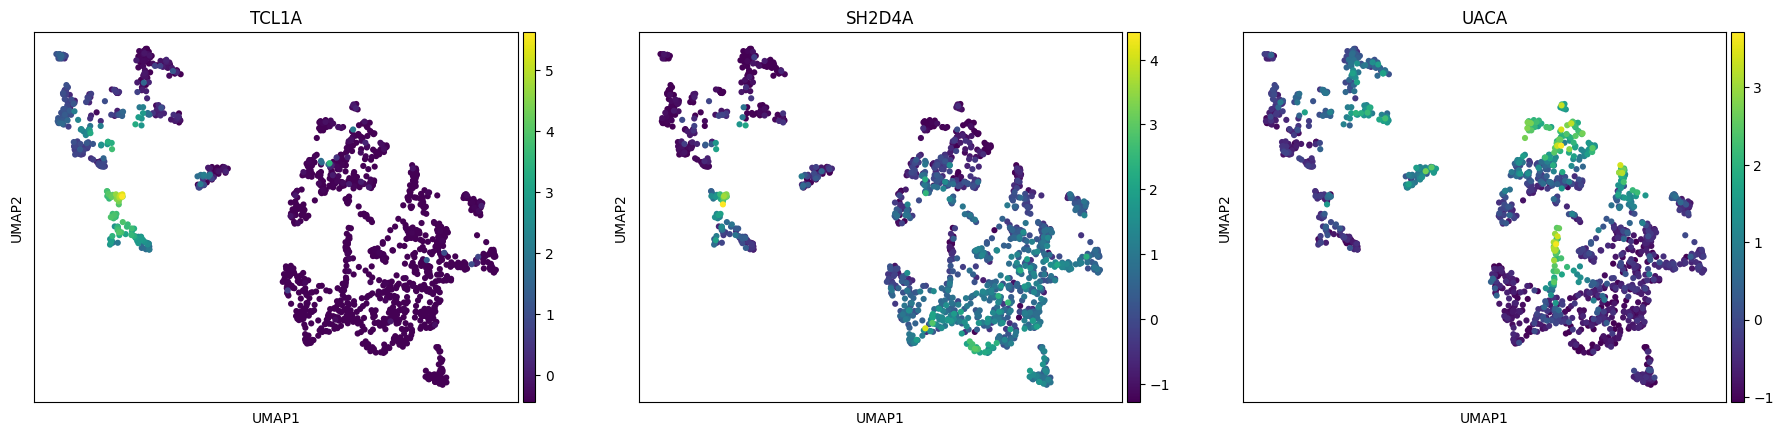

In [37]:
sc.pl.umap(adata, color=['TCL1A', 'SH2D4A',"UACA"])

Alternatively, we can compute a tSNE to visualize single cell data in 2D. Although UMAPs are generally better for capturing relationships between data points. tSNEs can provide a good view on distinct clusters.

In [38]:
sc.tl.tsne(adata, n_pcs=40)

/usr/local/lib/python3.8/dist-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(


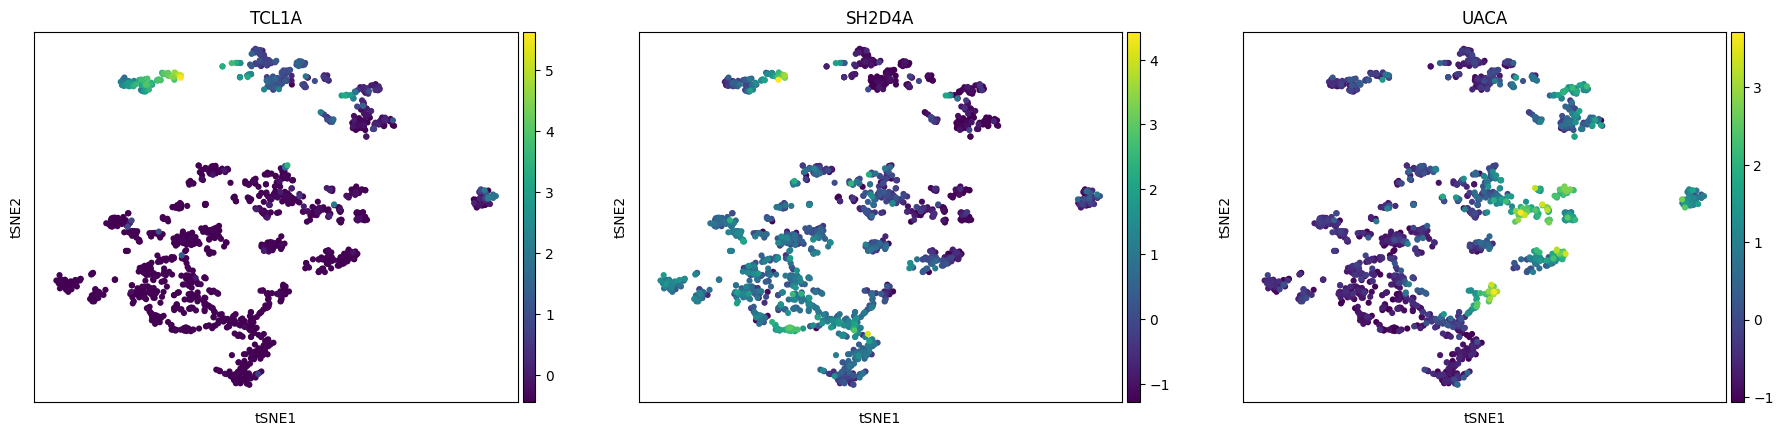

In [39]:
sc.pl.tsne(adata, color=['TCL1A', 'SH2D4A',"UACA"], use_raw=False)

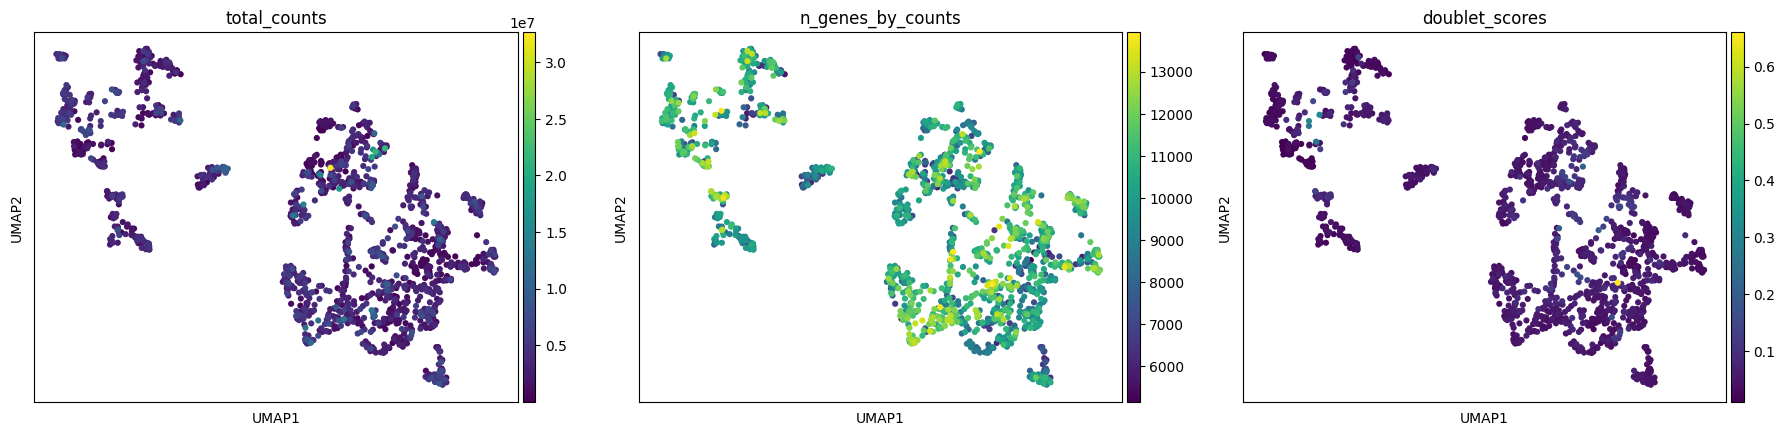

In [40]:
sc.pl.umap(adata, color=['total_counts', 'n_genes_by_counts', 'doublet_scores'], use_raw=False)

UMAPs (or tSNEs) can also be useful to inspect biases in the data such as low and high counts, or where doublets are located. The coordinates of embeddings are stored in `.obsm` entries

In [41]:
print(adata.obsm)
print(adata.obsm['X_umap'])
print(adata.obsm['X_umap'].shape)

AxisArrays with keys: X_pca, X_umap, X_tsne
[[ 7.770346   6.429046 ]
 [ 7.4667435  5.9917436]
 [14.459574   3.0536697]
 ...
 [-0.9532747  4.341327 ]
 [-2.8759713  5.9494977]
 [-2.7569182  5.369988 ]]
(1523, 2)


#### Clustering <a name="batch"></a>
Due to variations of non-biological factors during experiments, batch effects might occurs which is shown as variations in result data among the samples. Batch effects can be corrected with `harmony`.

**Observing batch effects**

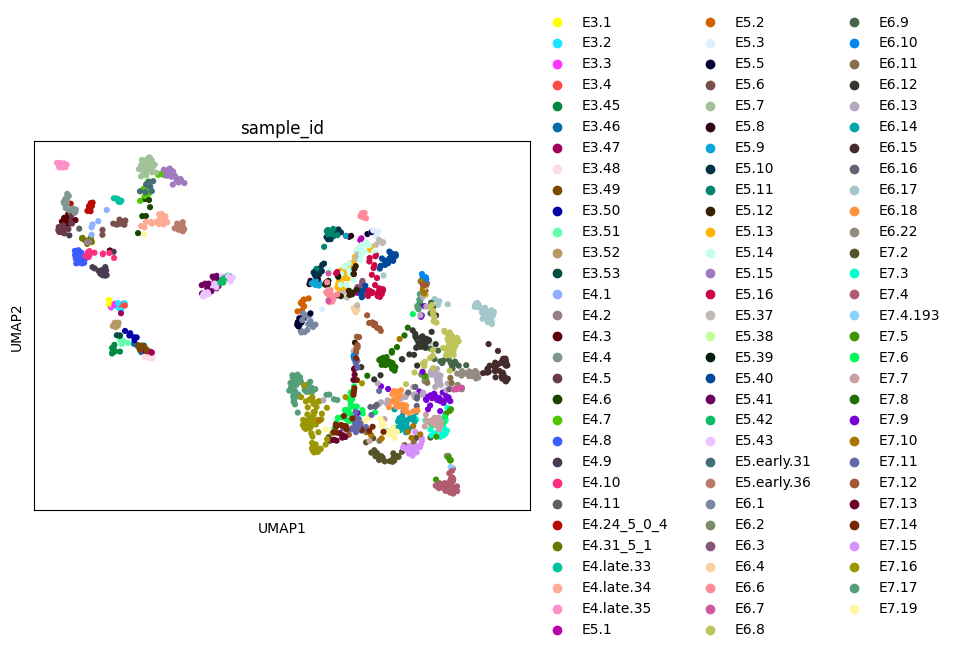

In [42]:
sc.pl.umap(adata, color="sample_id")

Using the neighborhood graph that we computed above with `sc.pp.neighbors`, we can perform Leiden clustering to group single cells. This will be useful for identifying cell types. For Leiden clustering, a clustering resolution can be specified where higher values will result in more clusters.
Per default Leiden clustering is saved as `leiden` entry in `.obs`.

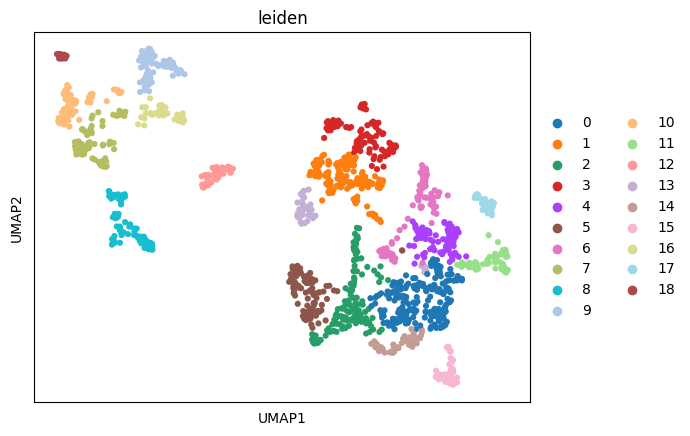

In [43]:
sc.tl.leiden(adata, resolution=0.6)
sc.pl.umap(adata, color=['leiden'])

Most of time, different clustering resolutions should be inspected depending on how fine or coarse grained the clustering of cells should be. We can automate this by looping over different resolutions and adding a key for each clustering resolution.

In [44]:
resolutions = [0.1, 0.4, 0.6, 1, 1.5, 2, 2.5, 3]

for res in resolutions:
    sc.tl.leiden(adata, resolution=res, key_added='leiden_' + str(res) )
adata.obs

,day_id,sample_id,predicted_doublets,doublet_scores,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,...,pct_counts_hb,leiden,leiden_0.1,leiden_0.4,leiden_0.6,leiden_1,leiden_1.5,leiden_2,leiden_2.5,leiden_3
E5.5.101,E5,E5.5,False,0.054845,8868,8868,380054.0,0.0,0.0,0.0,...,0.0,13,1,12,13,15,11,10,10,15
E5.5.100,E5,E5.5,False,0.051338,9376,9376,380586.0,0.0,0.0,0.0,...,0.0,13,1,12,13,15,11,10,10,15
E6.2.114,E6,E6.2,False,0.025610,7301,7301,341762.0,0.0,0.0,0.0,...,0.0,13,0,12,13,15,11,10,10,16
E6.2.104,E6,E6.2,False,0.062812,8117,8117,111158.0,0.0,0.0,0.0,...,0.0,0,0,0,0,15,11,10,10,16
E6.2.107,E6,E6.2,False,0.030928,6506,6506,148767.0,0.0,0.0,0.0,...,0.0,13,0,12,13,15,11,10,10,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E3.49.3407,E3,E3.49,False,0.030928,9509,9509,3191632.0,0.0,0.0,0.0,...,0.0,8,4,9,8,9,7,3,3,6
E3.51.3426,E3,E3.51,False,0.021109,10550,10548,6420873.0,0.0,0.0,0.0,...,0.0,8,4,9,8,9,7,3,3,6
E3.47.3391,E3,E3.47,False,0.037308,8965,8965,2673941.0,0.0,0.0,0.0,...,0.0,8,4,9,8,9,7,3,3,6
E3.52.3431,E3,E3.52,False,0.030928,9683,9683,3380835.0,0.0,0.0,0.0,...,0.0,8,4,9,8,9,7,3,3,27


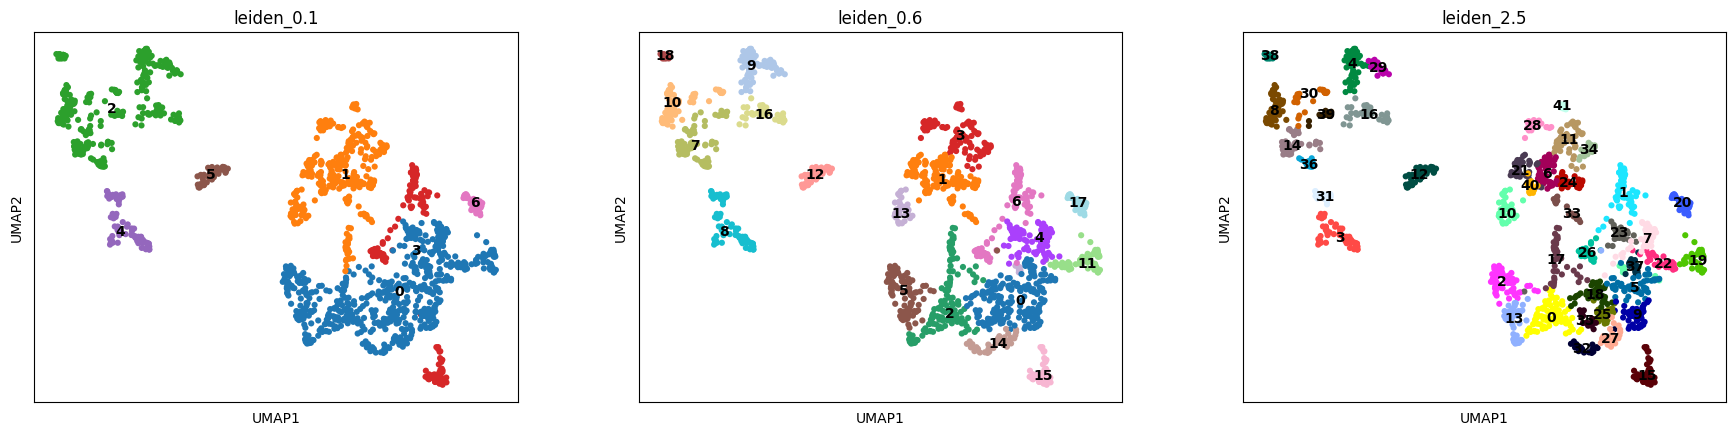

In [45]:
sc.pl.umap(adata, color=['leiden_0.1', 'leiden_0.6', 'leiden_2.5'], legend_loc='on data')

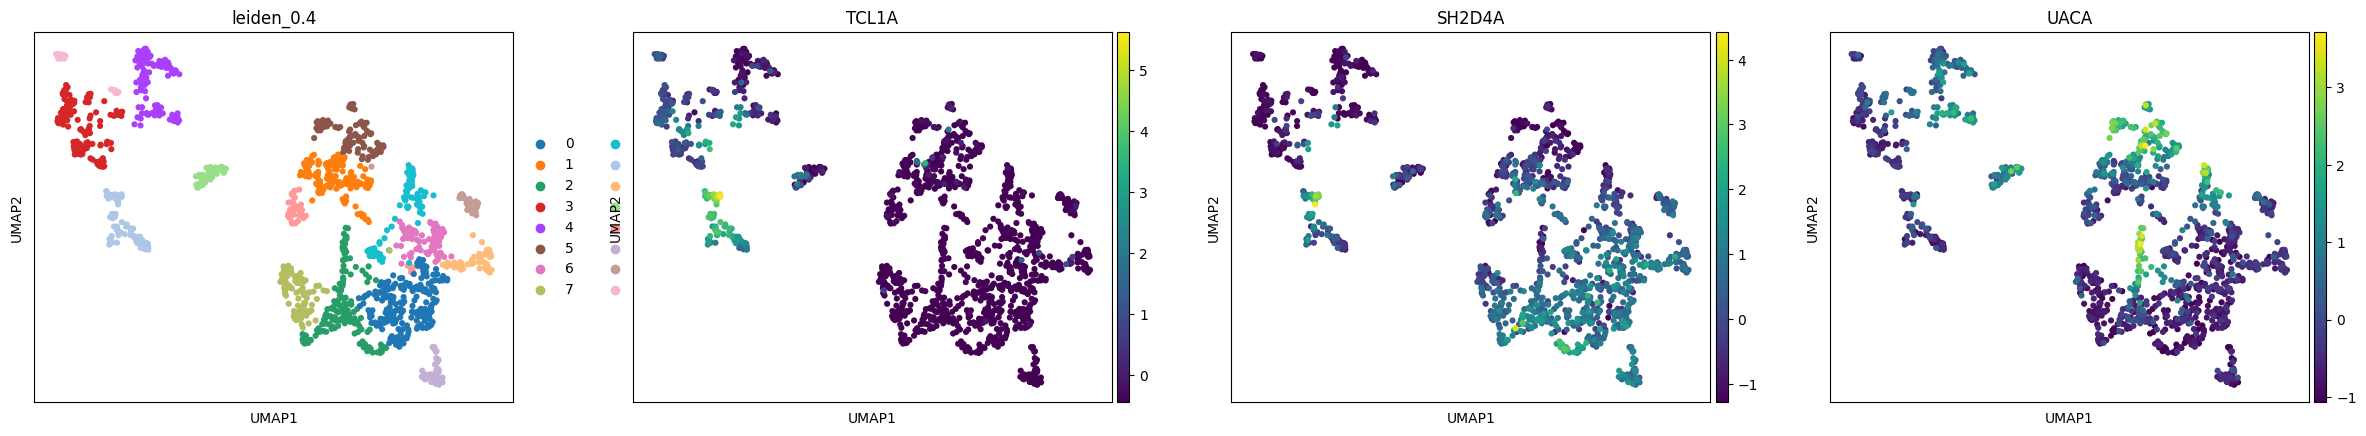

In [46]:
sc.pl.umap(adata, color=['leiden_0.4','TCL1A', 'SH2D4A',"UACA"])

#### Removing doublet clusters
Rather than just removing doublets seperately based on a threshold, it can be useful to remove clusters with a high doublet fraction. This way we also capture cells that would just be above a doublet threshold.

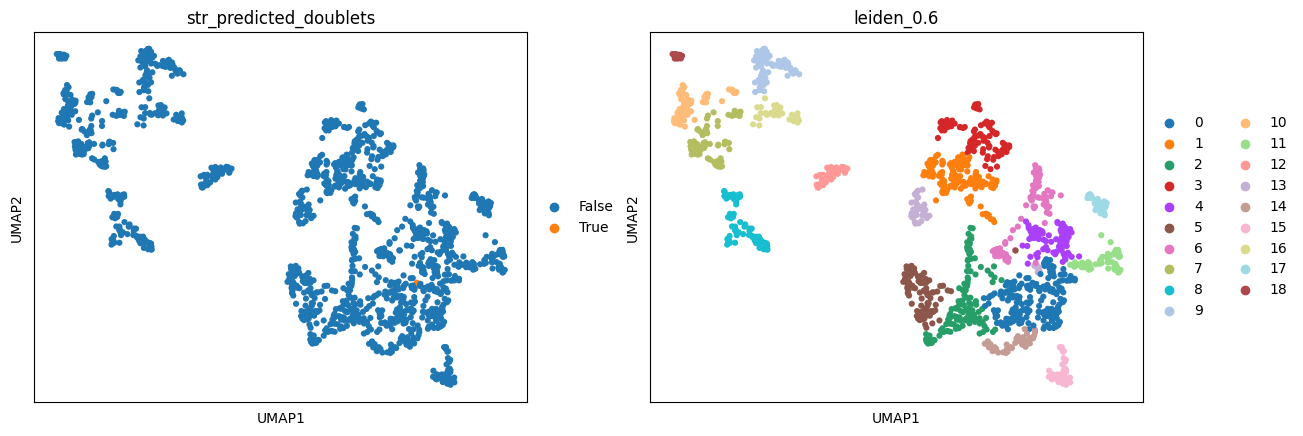

In [47]:
adata.obs['str_predicted_doublets'] = [str(dbl) for dbl in adata.obs['predicted_doublets']]
sc.pl.umap(adata, color=['str_predicted_doublets', 'leiden_0.6'])

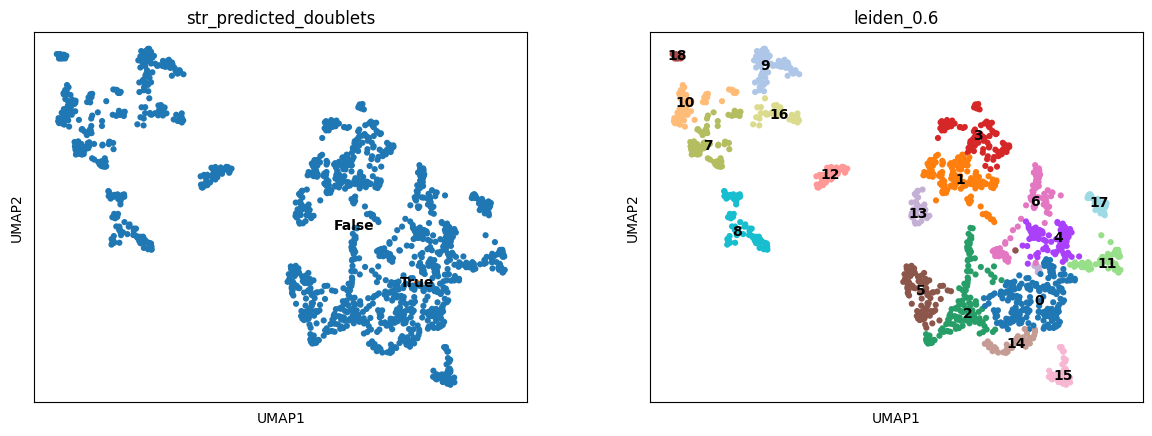

In [48]:
sc.pl.umap(adata, color=['str_predicted_doublets', 'leiden_0.6'], legend_loc='on data')

We can compute the fraction of doublets for each cluster using a rather high clustering resolution. This fraction can then be used to clean up our data before computing marker genes.

In [49]:
# what is fraction of doublets per cluster
import numpy as np
import pandas as pd

# init lists
list_clusters = np.unique(adata.obs['leiden_2'])
list_size = []
list_frac_doublets = []

# loop over clusters
for clus in list_clusters:
    clus_adata = adata[adata.obs['leiden_2'] == clus]
    
    size = clus_adata.shape[0]
    n_doublets = sum( clus_adata.obs['predicted_doublets'])
    
    list_frac_doublets.append( n_doublets / size )
    list_size.append(size)
    
df_frac_doublets = pd.DataFrame(
{
    'cluster': list_clusters,
    'size': list_size,
    'frac_doublets': list_frac_doublets
}
)

In [50]:
df_frac_doublets.sort_values('frac_doublets', ascending=False)

,cluster,size,frac_doublets
35,7,52,0.019231
0,0,77,0.000000
28,34,15,0.000000
21,28,24,0.000000
22,29,24,0.000000
23,3,59,0.000000
24,30,24,0.000000
25,31,22,0.000000
26,32,20,0.000000
27,33,17,0.000000


In [51]:
doublet_clusters = [ clus for clus 
                    in df_frac_doublets[ df_frac_doublets['frac_doublets'] >= 0.3 ]['cluster'] ]
doublet_clusters

[]

No doublet cluster

In [52]:
print(adata)
print(adata.shape)

AnnData object with n_obs × n_vars = 1523 × 23633
    obs: 'day_id', 'sample_id', 'predicted_doublets', 'doublet_scores', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'leiden', 'leiden_0.1', 'leiden_0.4', 'leiden_0.6', 'leiden_1', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'str_predicted_doublets'
    var: 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'day_id_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'tsne', 'sample_id_colors', 'leiden', 'leiden_colors', 'leiden_0.1_colors', 'leiden_0.6_colors', 'leiden_2.5_colors', 'leiden_0.4_colors', 'str_predicted_doublets_colors'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
(1523, 23633)


#### Marker genes <a name="mark"></a>
we can start computing marker genes for clusters to help us understand their characteristics. This is also useful for annotating them for example as different cell types. `sc.pl.rank_genes_groups` can be used for plotting the top marker genes per cluster. The second argument specifies the clustering or annotation for which we compute. Here we use the Leiden clustering with resolution 0.6 `leiden_0.6`. We also specify the key for storing the clustering `key_added`. SCANPY offer different ways for computing marker genes. Per default we collect all cells from one cluster and compare them against all other cells. Methods for detecting marker genes are:
- `t-test`: t-test
- `wilcoxon`: Wilcoxon-ranksum test. This test usually works well on single cell data
- `logreg`: logistic regression (computational more demanding)
For more details see: 
https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.rank_genes_groups.html

Using `wilcoxon` method to rank genes in each cluster (based on resolution 0.6 `leiden_0.6`). Genes with highest scores are believed to be markers for that cluster.

/usr/local/lib/python3.8/dist-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


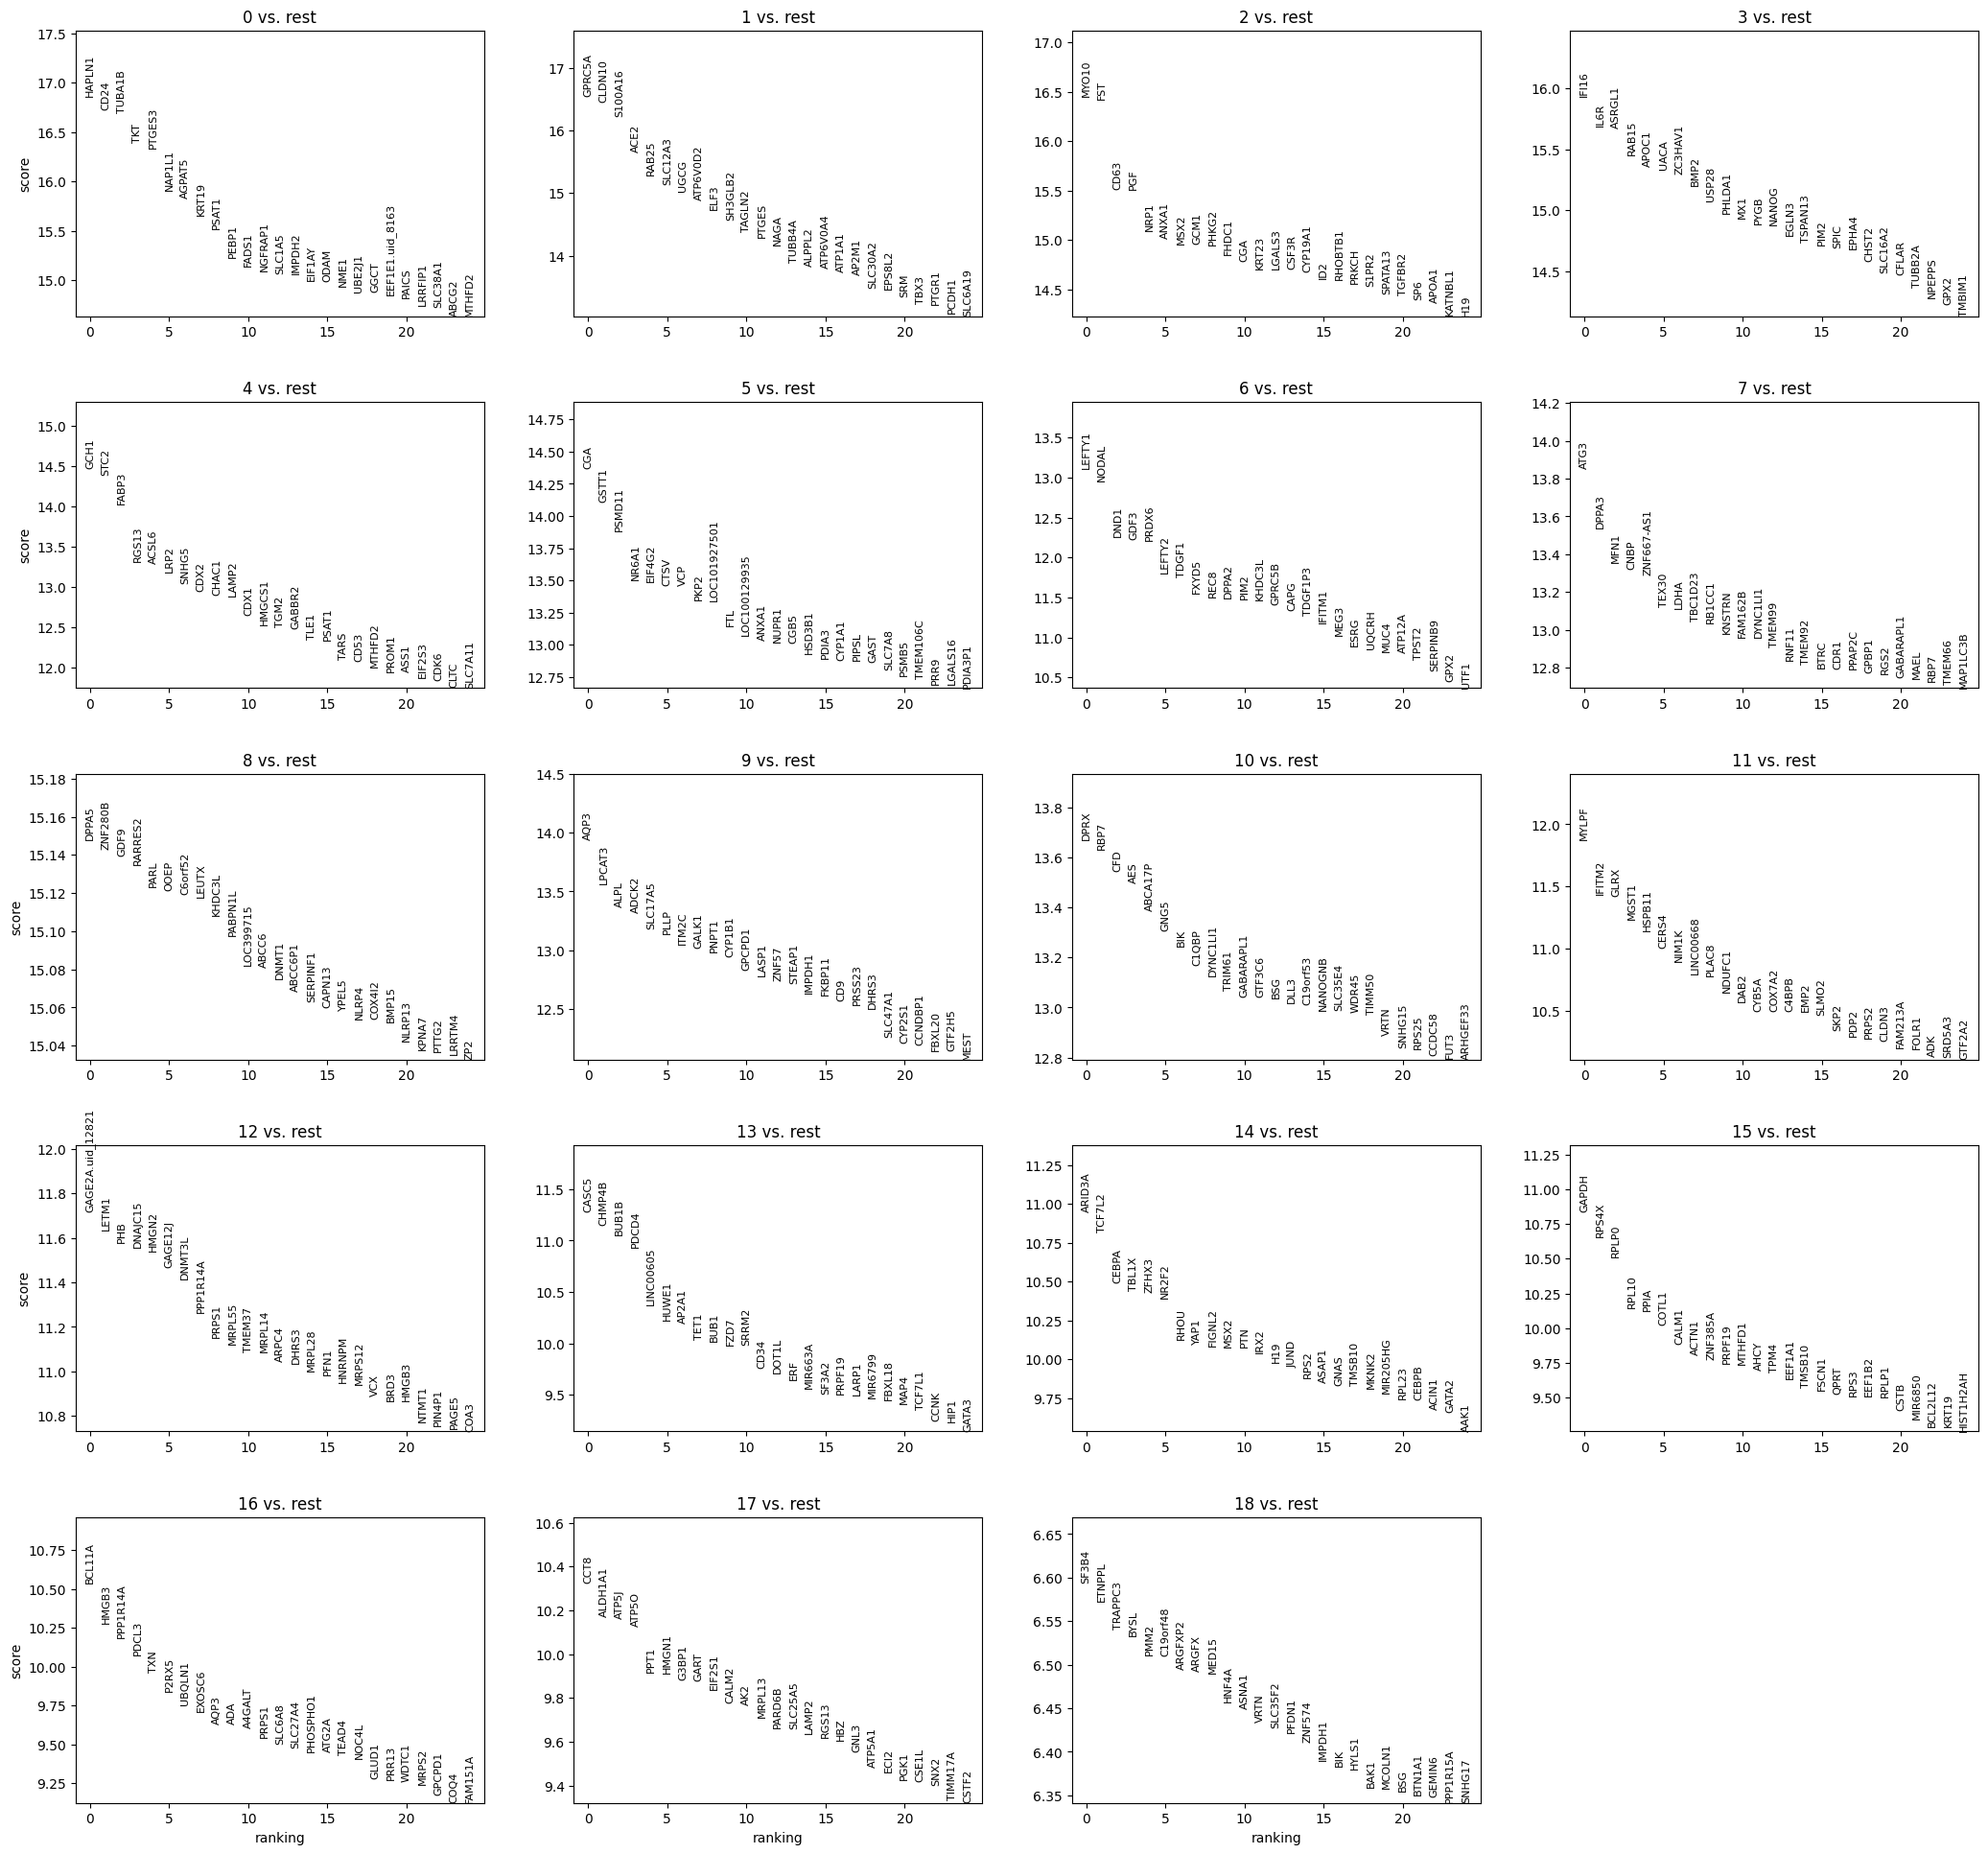

In [53]:
sc.tl.rank_genes_groups(adata, 'leiden_0.6', method='wilcoxon', use_raw=False, key_added='rank_leiden_0.6')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False, key='rank_leiden_0.6')

Marker genes and associated statistics are stored in `.uns`. In this case, `rank_leiden_0.6`.

In [54]:
adata.uns['rank_leiden_0.6'].keys()

dict_keys(['params', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges'])

Let's check the expression of the top marker genes("HAPLN1", "CD24","TUBA1B") on the UMAP

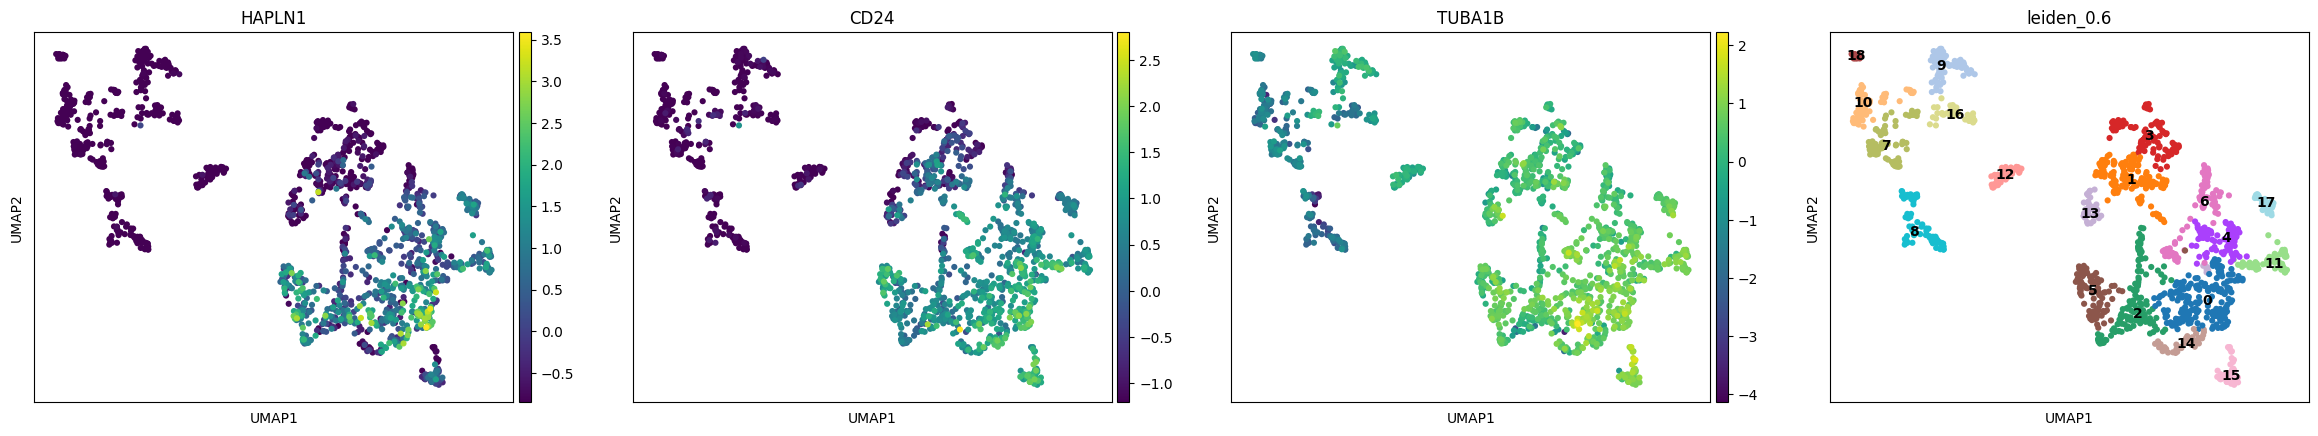

In [55]:
sc.pl.umap(adata, color=["HAPLN1", "CD24","TUBA1B", 'leiden_0.6'], legend_loc='on data')

#### Cell type annotation <a name="annotation"></a>

##### Adding metadata
In single-cell RNA sequencing (scRNA-seq), metadata refers to all the contextual or descriptive information associated with each cell or sample beyond the raw gene expression counts. This information helps researchers interpret and analyze the data properly. The file E-MTAB-3929.sdrf.txt is a characteristics table that includes multiple parameters related to the experiment.  Investigating meta data can be useful for understanding sample specific effects. We will add this meta data to our anndata object as additional `.obs` columns. The data is not from 10x Genomics Chromium platform and barcode are not used for the annotation. We will create our own labels to annotated clusters. These labels describe the developmental stage, embryonic day, and cell morphology classifications.

In [56]:
df_class=pd.read_csv("https://ftp.ebi.ac.uk/biostudies/fire/E-MTAB-/929/E-MTAB-3929/Files/E-MTAB-3929.sdrf.txt",sep="\t", index_col=0)
print(df_class.shape) 

(1529, 44)


We can observe 16 column values combination which represent 16 different developmental stage in our dataset. 
We can assign 16 categorical labels to describe our dataset. `Day3_NotApplicable`,`Day4_NotApplicable`,`Day4_Uncompacted`,`Day4_Compacted`,
`Day5_Epiblast`,`Day5_Trophectoderm`,`Day5_PrimitiveEndoderm`,`Day5_NotApplicable`,`Day6_TrophectodermMural`,`Day6_TrophectodermPolar`,
`Day6_PrimitiveEndoderm`,`Day6_Epiblast`, `Day7_TrophectodermPolar`,`Day7_TrophectodermMural`, `Day7_Epiblast`,`Day7_PrimitiveEndoderm`.
Because each embryo has different nutritional conditions or other conditions, the degree of cell development is not the same even on the same day. For example, lineage can not be detected in some cells on the 5th day

In [57]:
columns_to_extract = [
    'Characteristics[developmental stage]',
    'Characteristics[phenotype]',
    'Characteristics[inferred lineage]',
    'Characteristics[inferred trophectoderm subpopulation]'
]
df_label = df_class[columns_to_extract]
df_label.columns = ['day', 'phenotype', 'lineage', 'TE_subgroup']
unique_combinations = df_label.reset_index()[['day', 'phenotype', 'lineage', 'TE_subgroup']].drop_duplicates()
print(unique_combinations)

                  day       phenotype             lineage     TE_subgroup
0     embryonic day 3  not applicable      not applicable  not applicable
21    embryonic day 4  not applicable      not applicable  not applicable
49    embryonic day 4     Uncompacted      not applicable  not applicable
92    embryonic day 4       Compacted      not applicable  not applicable
211   embryonic day 5  not applicable            epiblast  not applicable
212   embryonic day 5  not applicable       trophectoderm  not applicable
214   embryonic day 5  not applicable  primitive endoderm  not applicable
216   embryonic day 5  not applicable      not applicable  not applicable
588   embryonic day 6  not applicable       trophectoderm           mural
591   embryonic day 6  not applicable       trophectoderm           polar
604   embryonic day 6  not applicable  primitive endoderm  not applicable
607   embryonic day 6  not applicable            epiblast  not applicable
1003  embryonic day 7  not applicable 

In [58]:
# define assign_label function
def assign_label(row):
    if row['day'] == 'embryonic day 3':
        return 'Day3_NotApplicable'
    elif row['day'] == 'embryonic day 4' and row['phenotype'] == 'not applicable':
        return 'Day4_NotApplicable'
    elif row['day'] == 'embryonic day 4' and row['phenotype'] == 'Uncompacted':
        return 'Day4_Uncompacted'
    elif row['day'] == 'embryonic day 4' and row['phenotype'] == 'Compacted':
        return 'Day4_Compacted'
    elif row['day'] == 'embryonic day 5' and row['lineage'] == 'epiblast':
        return 'Day5_Epiblast'
    elif row['day'] == 'embryonic day 5' and row['lineage'] == 'trophectoderm':
        return 'Day5_Trophectoderm'
    elif row['day'] == 'embryonic day 5' and row['lineage'] == 'primitive endoderm':
        return 'Day5_PrimitiveEndoderm'
    elif row['day'] == 'embryonic day 5':
        return 'Day5_NotApplicable'
    elif row['day'] == 'embryonic day 6' and row['lineage'] == 'trophectoderm' and row['TE_subgroup'] == 'mural':
        return 'Day6_TrophectodermMural'
    elif row['day'] == 'embryonic day 6' and row['lineage'] == 'trophectoderm' and row['TE_subgroup'] == 'polar':
        return 'Day6_TrophectodermPolar'
    elif row['day'] == 'embryonic day 6' and row['lineage'] == 'primitive endoderm':
        return 'Day6_PrimitiveEndoderm'
    elif row['day'] == 'embryonic day 6' and row['lineage'] == 'epiblast':
        return 'Day6_Epiblast'
    elif row['day'] == 'embryonic day 7' and row['lineage'] == 'trophectoderm' and row['TE_subgroup'] == 'polar':
        return 'Day7_TrophectodermPolar'
    elif row['day'] == 'embryonic day 7' and row['lineage'] == 'trophectoderm' and row['TE_subgroup'] == 'mural':
        return 'Day7_TrophectodermMural'
    elif row['day'] == 'embryonic day 7' and row['lineage'] == 'epiblast':
        return 'Day7_Epiblast'
    elif row['day'] == 'embryonic day 7' and row['lineage'] == 'primitive endoderm':
        return 'Day7_PrimitiveEndoderm'
    else:
        return 'Unknown'

df_label['Category'] = df_label.apply(assign_label, axis=1)

/tmp/ipykernel_1702625/3590972196.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_label['Category'] = df_label.apply(assign_label, axis=1)


In [59]:
adata.obs = adata.obs.join(df_label, how='left')

In [60]:
adata.obs

,day_id,sample_id,predicted_doublets,doublet_scores,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,...,leiden_1.5,leiden_2,leiden_2.5,leiden_3,str_predicted_doublets,day,phenotype,lineage,TE_subgroup,Category
E5.5.101,E5,E5.5,False,0.054845,8868,8868,380054.0,0.0,0.0,0.0,...,11,10,10,15,False,embryonic day 5,not applicable,trophectoderm,not applicable,Day5_Trophectoderm
E5.5.100,E5,E5.5,False,0.051338,9376,9376,380586.0,0.0,0.0,0.0,...,11,10,10,15,False,embryonic day 5,not applicable,trophectoderm,not applicable,Day5_Trophectoderm
E6.2.114,E6,E6.2,False,0.025610,7301,7301,341762.0,0.0,0.0,0.0,...,11,10,10,16,False,embryonic day 6,not applicable,trophectoderm,mural,Day6_TrophectodermMural
E6.2.104,E6,E6.2,False,0.062812,8117,8117,111158.0,0.0,0.0,0.0,...,11,10,10,16,False,embryonic day 6,not applicable,trophectoderm,mural,Day6_TrophectodermMural
E6.2.107,E6,E6.2,False,0.030928,6506,6506,148767.0,0.0,0.0,0.0,...,11,10,10,16,False,embryonic day 6,not applicable,trophectoderm,mural,Day6_TrophectodermMural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E3.49.3407,E3,E3.49,False,0.030928,9509,9509,3191632.0,0.0,0.0,0.0,...,7,3,3,6,False,embryonic day 3,not applicable,not applicable,not applicable,Day3_NotApplicable
E3.51.3426,E3,E3.51,False,0.021109,10550,10548,6420873.0,0.0,0.0,0.0,...,7,3,3,6,False,embryonic day 3,not applicable,not applicable,not applicable,Day3_NotApplicable
E3.47.3391,E3,E3.47,False,0.037308,8965,8965,2673941.0,0.0,0.0,0.0,...,7,3,3,6,False,embryonic day 3,not applicable,not applicable,not applicable,Day3_NotApplicable
E3.52.3431,E3,E3.52,False,0.030928,9683,9683,3380835.0,0.0,0.0,0.0,...,7,3,3,27,False,embryonic day 3,not applicable,not applicable,not applicable,Day3_NotApplicable


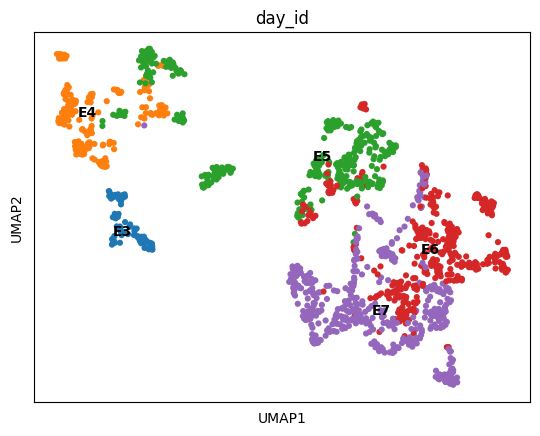

In [61]:
sc.pl.umap(adata, color=['day_id'], legend_loc='on data')

Among top-ranked EPI-specific genes were factors implicated in embryonic preimplantation development in mouse or human, such as PRDM14, GDF3, TDGF1, NODAL, SOX2, and NANOG. PE-specific genes included known factors such as COL4A1, HNF1B, PDGFRA, GATA4 and FN1 (rank 3, 4, 7, 13, and 15)

In [62]:
# Significant genes were grouped according to day_id
sc.tl.rank_genes_groups(adata, groupby='day_id', method='t-test', key_added='rank_day_id')

/usr/local/lib/python3.8/dist-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


In [63]:
import pandas as pd

# Extract the result of rank_genes_groups
ranked_genes = pd.DataFrame(adata.uns['rank_day_id']['names']).head(3)

# Print result
for day in ['E3', 'E4', 'E5', 'E6', 'E7']:
    print(f"Day {day} top 2 genes: {ranked_genes[day].values}")


Day E3 top 2 genes: ['DPPA5' 'GDF9' 'PTTG1']
Day E4 top 2 genes: ['GABARAPL1' 'MTMR14' 'FOXR1']
Day E5 top 2 genes: ['NLRP7' 'TUBB4A' 'SEPW1']
Day E6 top 2 genes: ['FABP3' 'TARS' 'HMGCS1']
Day E7 top 2 genes: ['CCKBR' 'PTN' 'TMSB10']


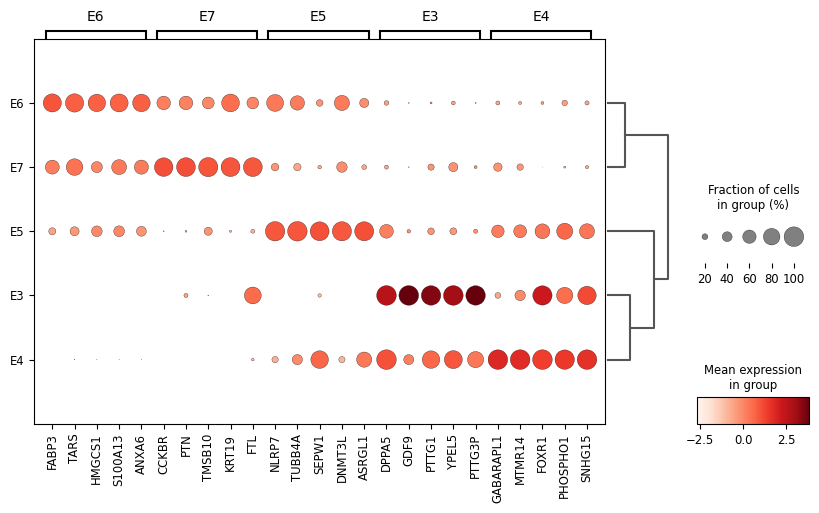

In [64]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=5, key='rank_day_id', groupby='day_id', figsize=(10, 5))


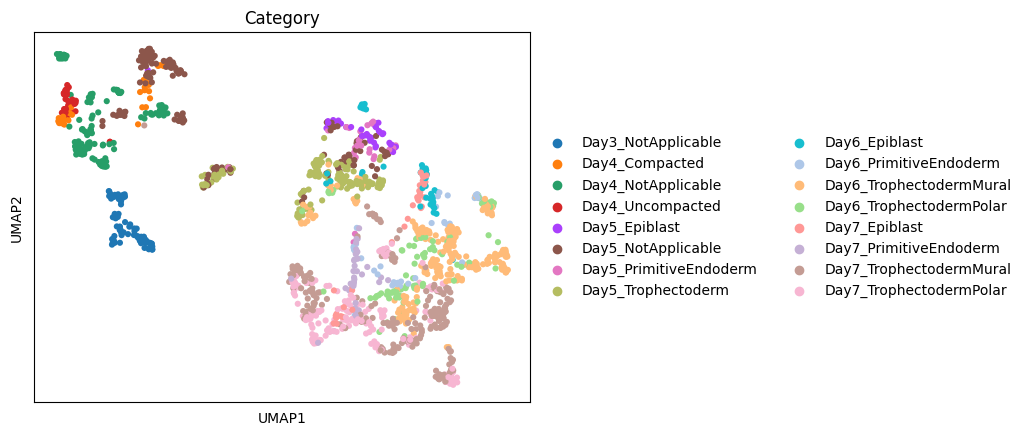

In [65]:
sc.pl.umap(adata, color=['Category'])

#### predict cell linage

The number of significantly differentially expressed genes between embryonic time-points. From E5 to E7 the differential expression analysis was done within lineages. The zygote establishes three distinct cell types in the mature blastocyst: `trophectoderm (TE)`, `primitive endoderm (PE)`, and `epiblast (EPI)`. 

`trophectoderm (TE)`: Represents cells that contribute to the placenta. 

`primitive endoderm (PE)`: Represents cells that contribute to the yolk sac 

`epiblast (EPI)`: Represents cells that will form the future embryo 

According to some research based on mouse, TE and the inner cell mass (ICM) segregate first, and this is controlled by the opposing transcription factors caudal type homeobox 2 (CDX2) and POU domain class 5 transcription factor 1 (POU5F1, also known as OCTCT3/4) (Niwa et al., 2005). CDX2 repress POU5F1 expression in these outer cells, driving specification and maturation of the TE and ICM (Niwa et al., 2005). However, we will fouse on how the divergence of the ICM into pluripotent EPI and PE occurs in human on `day 7` .


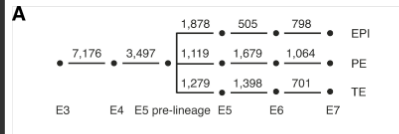

In [66]:
sub_adata = adata[adata.obs["day_id"].isin(["E7"])].copy()

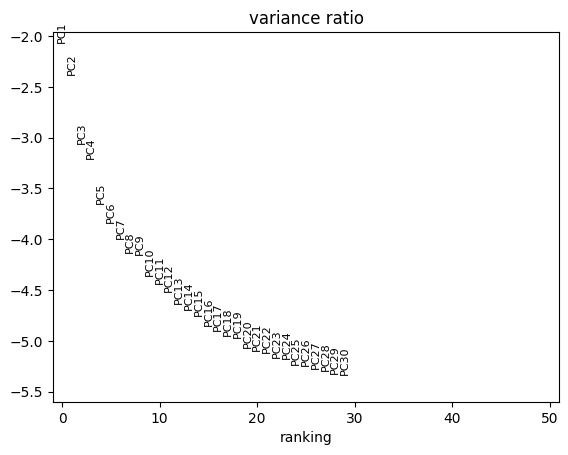

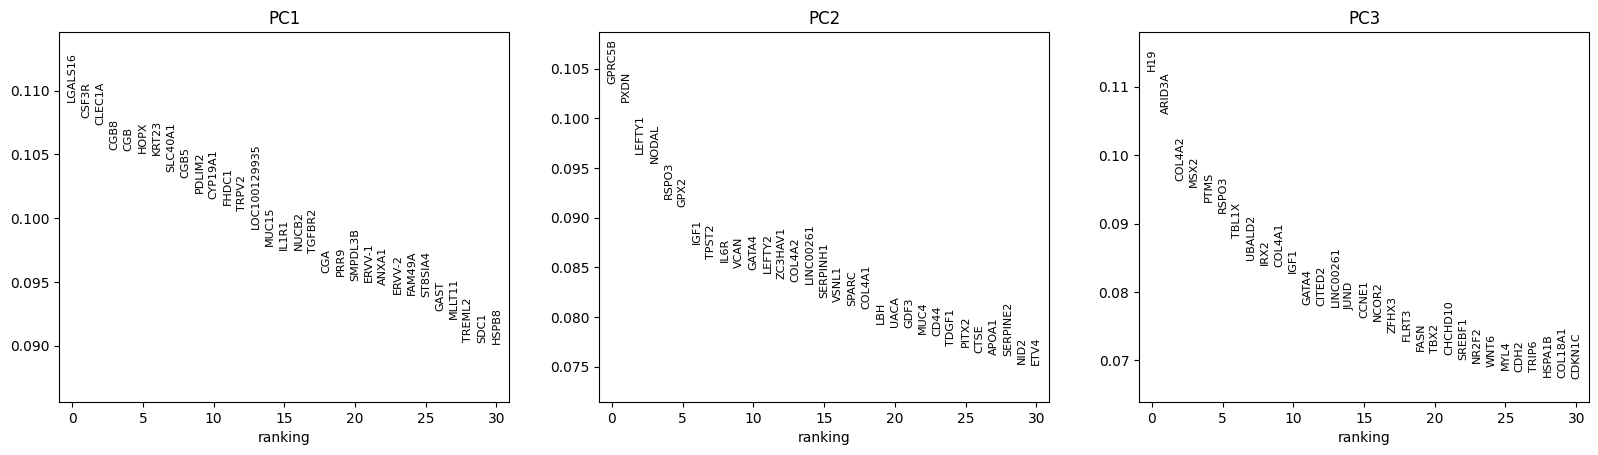

In [67]:
sc.pp.pca(sub_adata, n_comps=30, use_highly_variable=True)
sc.pl.pca_variance_ratio(sub_adata, log=True, n_pcs=50)
sc.pl.pca_loadings(sub_adata, include_lowest=False)

In [68]:
sc.tl.leiden(sub_adata, resolution=0.1, key_added='leiden_0.1')

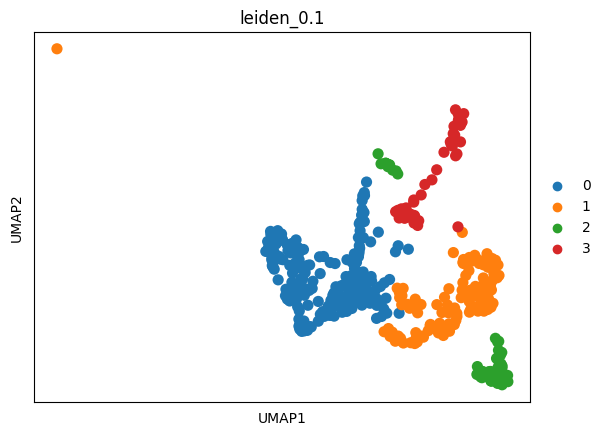

In [69]:
sc.pl.umap(sub_adata, color=['leiden_0.1'])

In [70]:
sub_adata.obs["leiden_0.1"]

E7.2.138     1
E7.2.144     1
E7.2.148     1
E7.2.139     1
E7.2.164     1
            ..
E7.14.905    0
E7.14.893    1
E7.14.913    0
E7.14.907    0
E7.14.909    0
Name: leiden_0.1, Length: 462, dtype: category
Categories (4, object): ['0', '1', '2', '3']

/usr/local/lib/python3.8/dist-packages/scanpy/tools/_rank_genes_groups.py:420: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, 'logfoldchanges'] = np.log2(


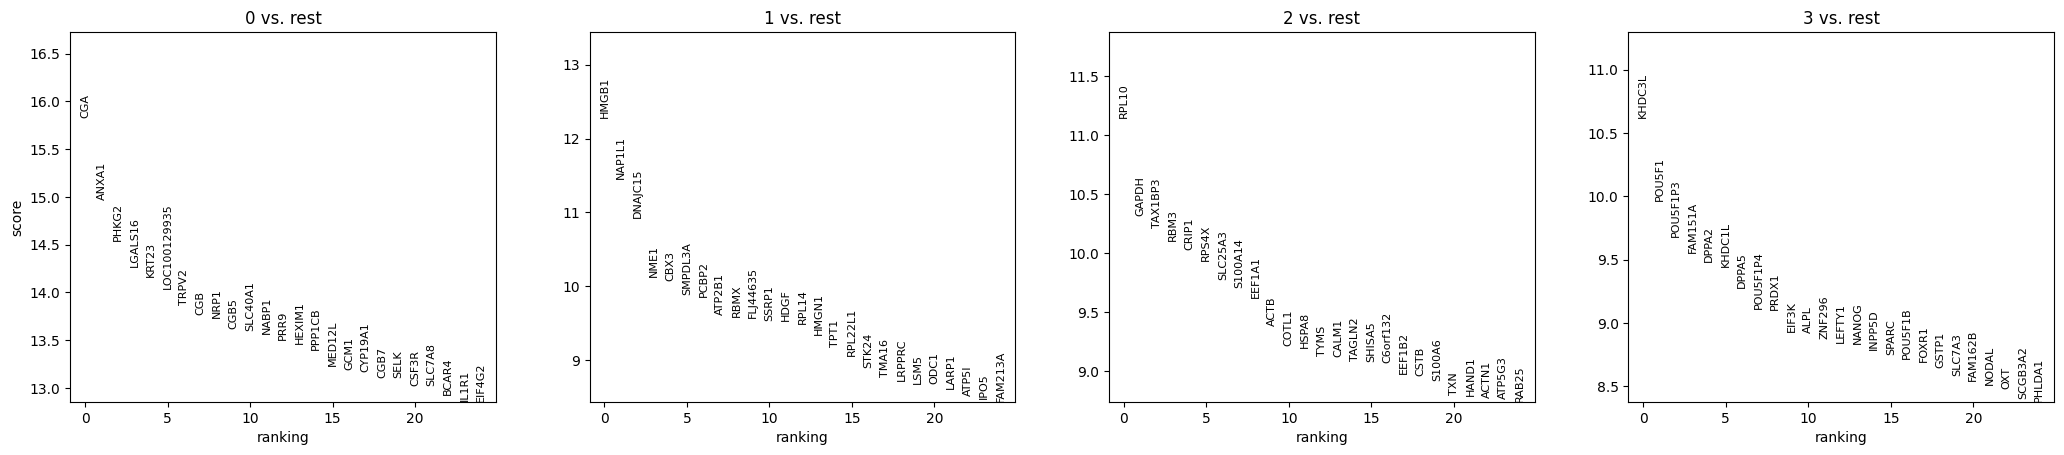

In [71]:
sc.tl.rank_genes_groups(sub_adata, 'leiden_0.1', method='wilcoxon', use_raw=False, key_added='rank_leiden_0.1')
sc.pl.rank_genes_groups(sub_adata, n_genes=25, sharey=False, key='rank_leiden_0.1')

`'TDGF1', 'NANOG',"SOX2"` are key genes commonly associated with `EPI`, NANOG and SOX2 are core pluripotency transcription factors. Along with OCT4, they help maintain the self-renewal and undifferentiated state of embryonic stem cells.TDGF1 (often referred to as Cripto in mammals) is involved in early embryonic signaling pathways (particularly the Nodal signaling pathway) that regulate cell fate decisions, including pluripotency and differentiation into various lineages.

`PDGFRA, GATA4, and SOX17` are key markers associated with the `primitive endoderm(PE)`
These markers help distinguish the primitive endoderm from the epiblast (EPI) and trophectoderm lineages during the blastocyst stage and later in embryonic development.

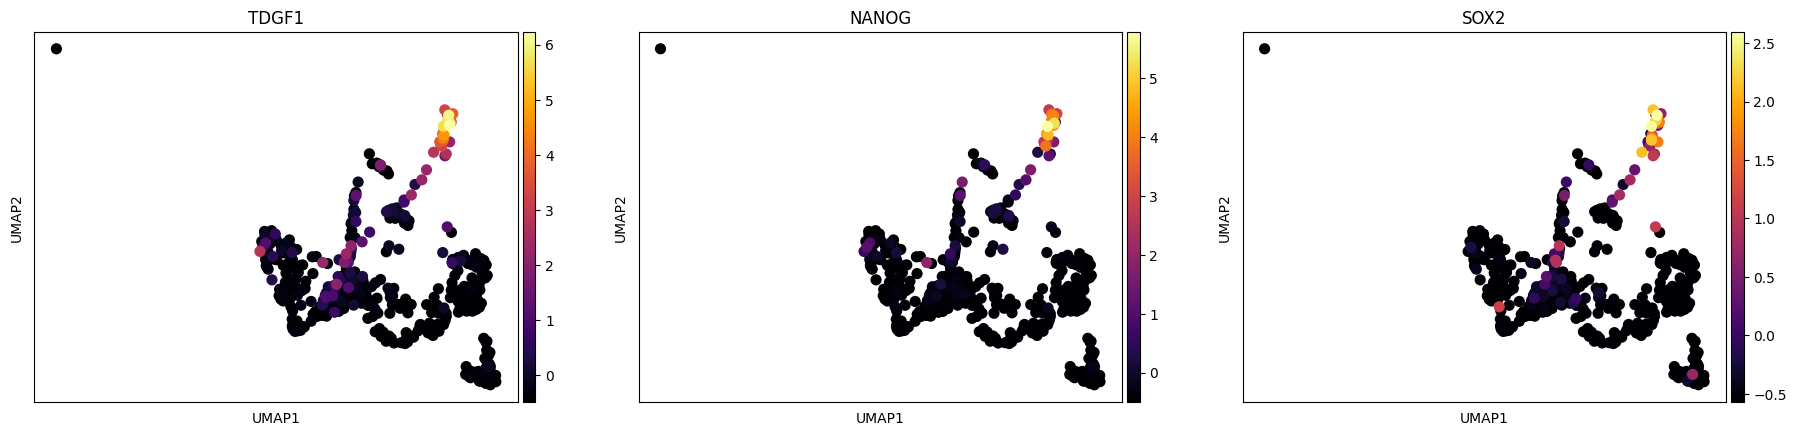

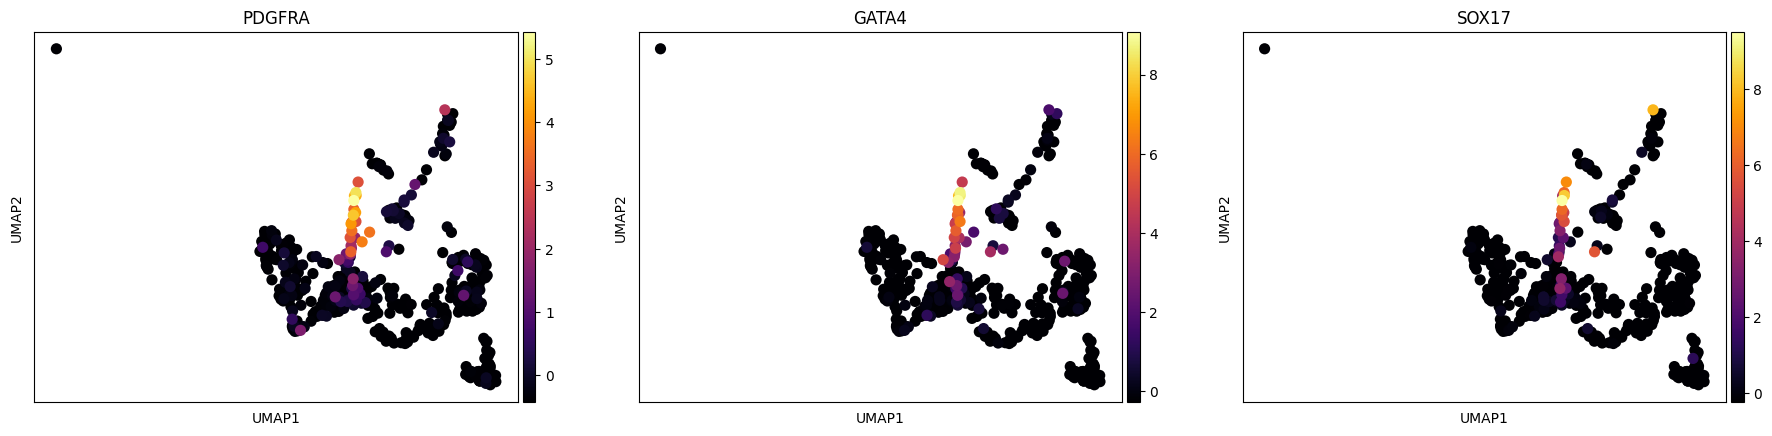

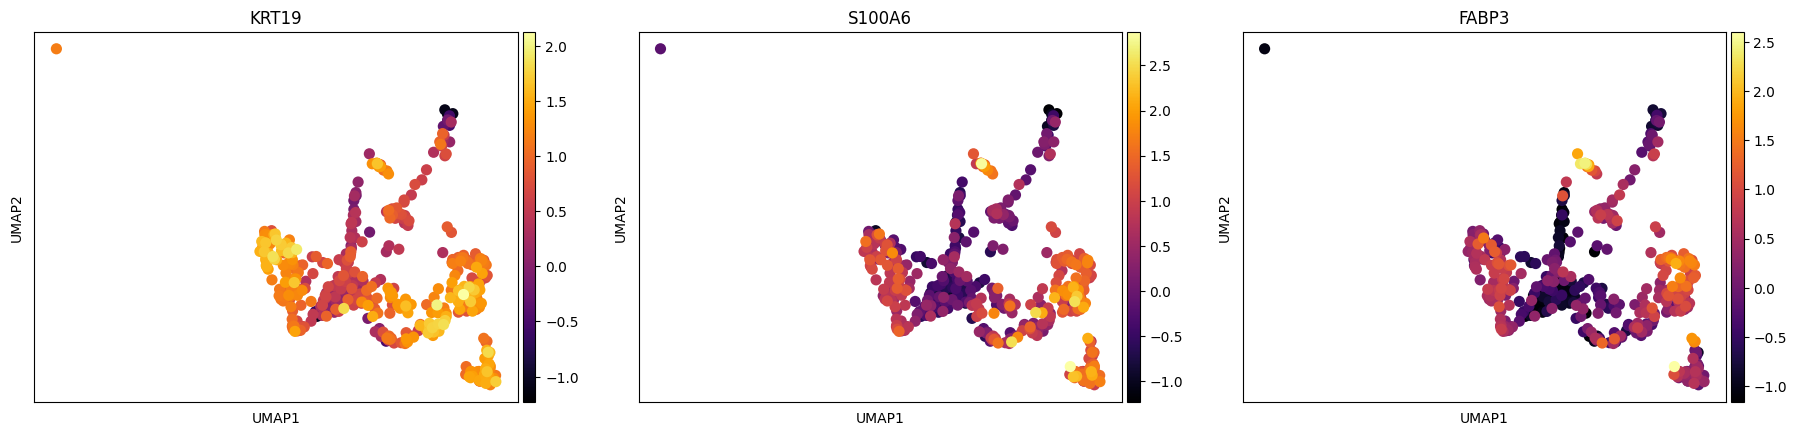

In [72]:
sc.pl.umap(sub_adata , color=['TDGF1', 'NANOG',"SOX2"], cmap='inferno', legend_loc='on data') #EPI
sc.pl.umap(sub_adata, color=["PDGFRA","GATA4","SOX17"], cmap='inferno', legend_loc='on data') #PE
sc.pl.umap(sub_adata, color=["KRT19","S100A6","FABP3"], cmap='inferno', legend_loc='on data') #TE

In [73]:
dict_annotate_clusters = {
    '3': 'epiblast ',
    '0':'primitive endoderm',
    '1':'trophectoderm'}

sub_adata.obs['celltype'] = [ dict_annotate_clusters[cluster] if cluster in dict_annotate_clusters.keys()
                        else 'unknown_cluster' + cluster
                        for cluster in sub_adata.obs['leiden_0.1'] ]

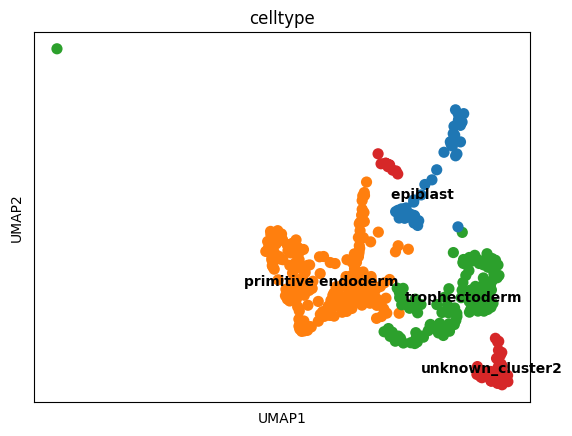

In [74]:
sc.pl.umap(sub_adata, color=['celltype'], legend_loc='on data')

## Functional Analysis
Looking deep into EPI cell type that will form the future embryo. The genes list in these clusters above are written into table with their log fold change and p-values for functional analysis. The log fold change is used to determine which genes are upregulated or downregulated in EPI cells (with a threshold of 1 va p_adjusted < 0.05). The upregulated genes will then be analyzed via iRegulon for motif discovery.

In [75]:
df_ranked_genes = sc.get.rank_genes_groups_df(sub_adata, ['3'], key='rank_leiden_0.1')
outf = outdir + "/EPI_rank_leiden_0.1.tsv"
df_ranked_genes.to_csv(outf, sep="\t", index=None)

In [76]:
sub_adata.uns.keys()

dict_keys(['day_id_colors', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'tsne', 'sample_id_colors', 'leiden', 'leiden_colors', 'leiden_0.1_colors', 'leiden_0.6_colors', 'leiden_2.5_colors', 'leiden_0.4_colors', 'str_predicted_doublets_colors', 'rank_leiden_0.6', 'rank_day_id', 'dendrogram_day_id', 'Category_colors', 'rank_leiden_0.1', 'celltype_colors'])

In [77]:
!head -4 ./Output/EPI_rank_leiden_0.1.tsv

names	scores	logfoldchanges	pvals	pvals_adj
KHDC3L	10.623453		2.3182421632225376e-26	5.478701704343823e-22
POU5F1	9.963007		2.2126793279309998e-23	2.614612527849666e-19
POU5F1P3	9.683083		3.558230997964389e-22	2.8030557724964134e-18


### Use the entire ranking to determine the "leading edge"

#### GORilla/GO Enrichment

In [78]:
!cat ./Output/EPI_rank_leiden_0.1.tsv | sort -k 3,3gr | awk '$3 != "NA" && $3 > 2 && $5 < 0.05 {print $1}' | grep -v names | head

GFPT2
BROX
LEFTY2
PLA2G10
INIP
DCP1A
RC3H1
CASC15
SPATA22
RPL39L


In [79]:
!cat ./Output/EPI_rank_leiden_0.1.tsv | sort -k 3,3gr | awk '$3 != "NA" && $3 > 2 && $5 < 0.05 {print $1}' | grep -v Gene > ./Output/upseq.results.sortFCdesc.txt

After clustering and annotating the cell types, one cell lineage is chosen for functional analysis (EPI).Significant genes in this cell type are related to nuclear-transcribed mRNA catabolic process, RNA metabolic process, establishment of protein localization to endoplasmic reticulum... Each biological process is linked to specific GO_id that can be find on GO database.
(18617,116,2142,38) there are 38 genes that are known to be involved in 'nuclear-transcribed mRNA catabolic process', within the top 2142 genes; while among all annotated 18617 genes in the human genome, there are 116 genes with this function. The expected frequency is 116/18617 while the observed frequency is 38/2142. The latter is significantly higher according to the binomial/hypergeometric distribution, since the adjusted p-value is 1.91E-8 which is smaller than 0.05.

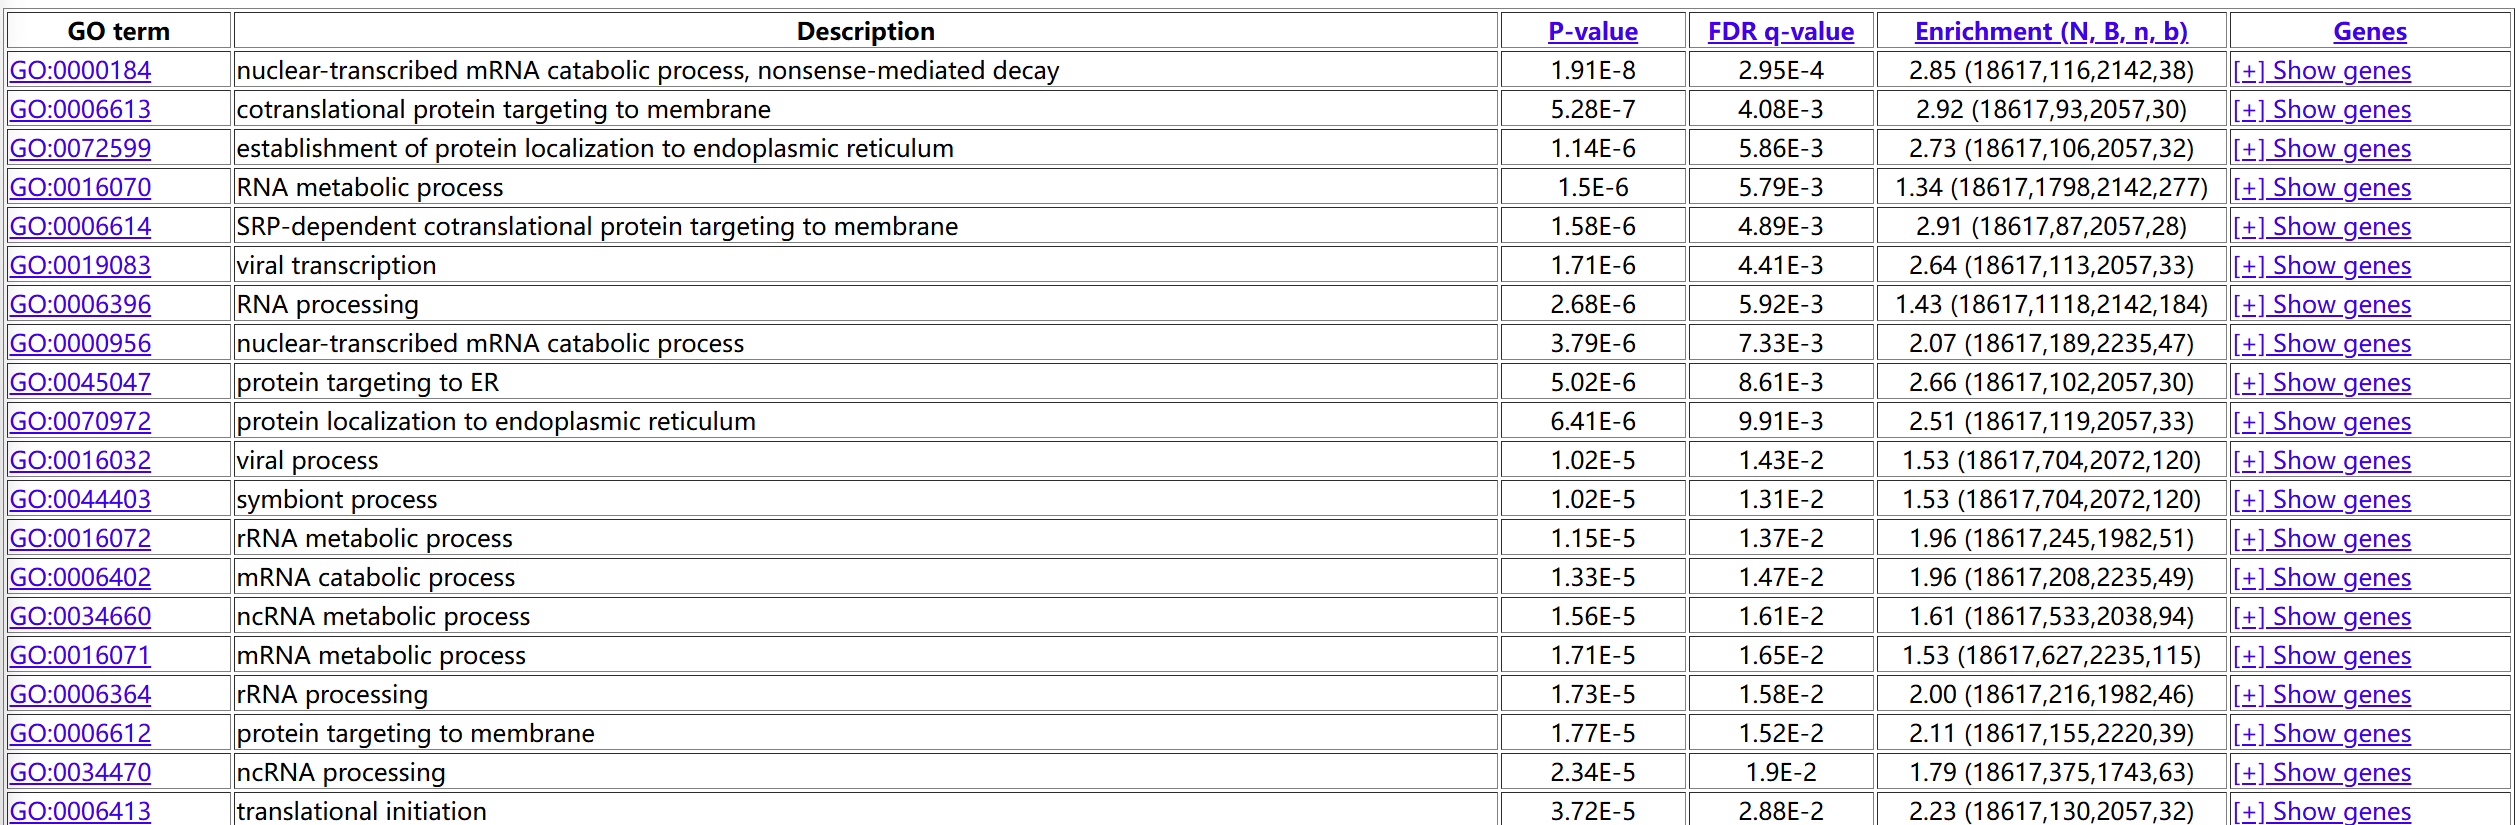

Do the same, but now for a ranked list in ascending order (most down-regulated gene on top):

In [80]:
!cat ./Output/EPI_rank_leiden_0.1.tsv | sort -k 3,3g | awk '$3 != "NA" && $3 < -2 && $5 < 0.05 {print $1}' | grep -v Gene > ./Output/downseq.results.sortFCdesc.txt

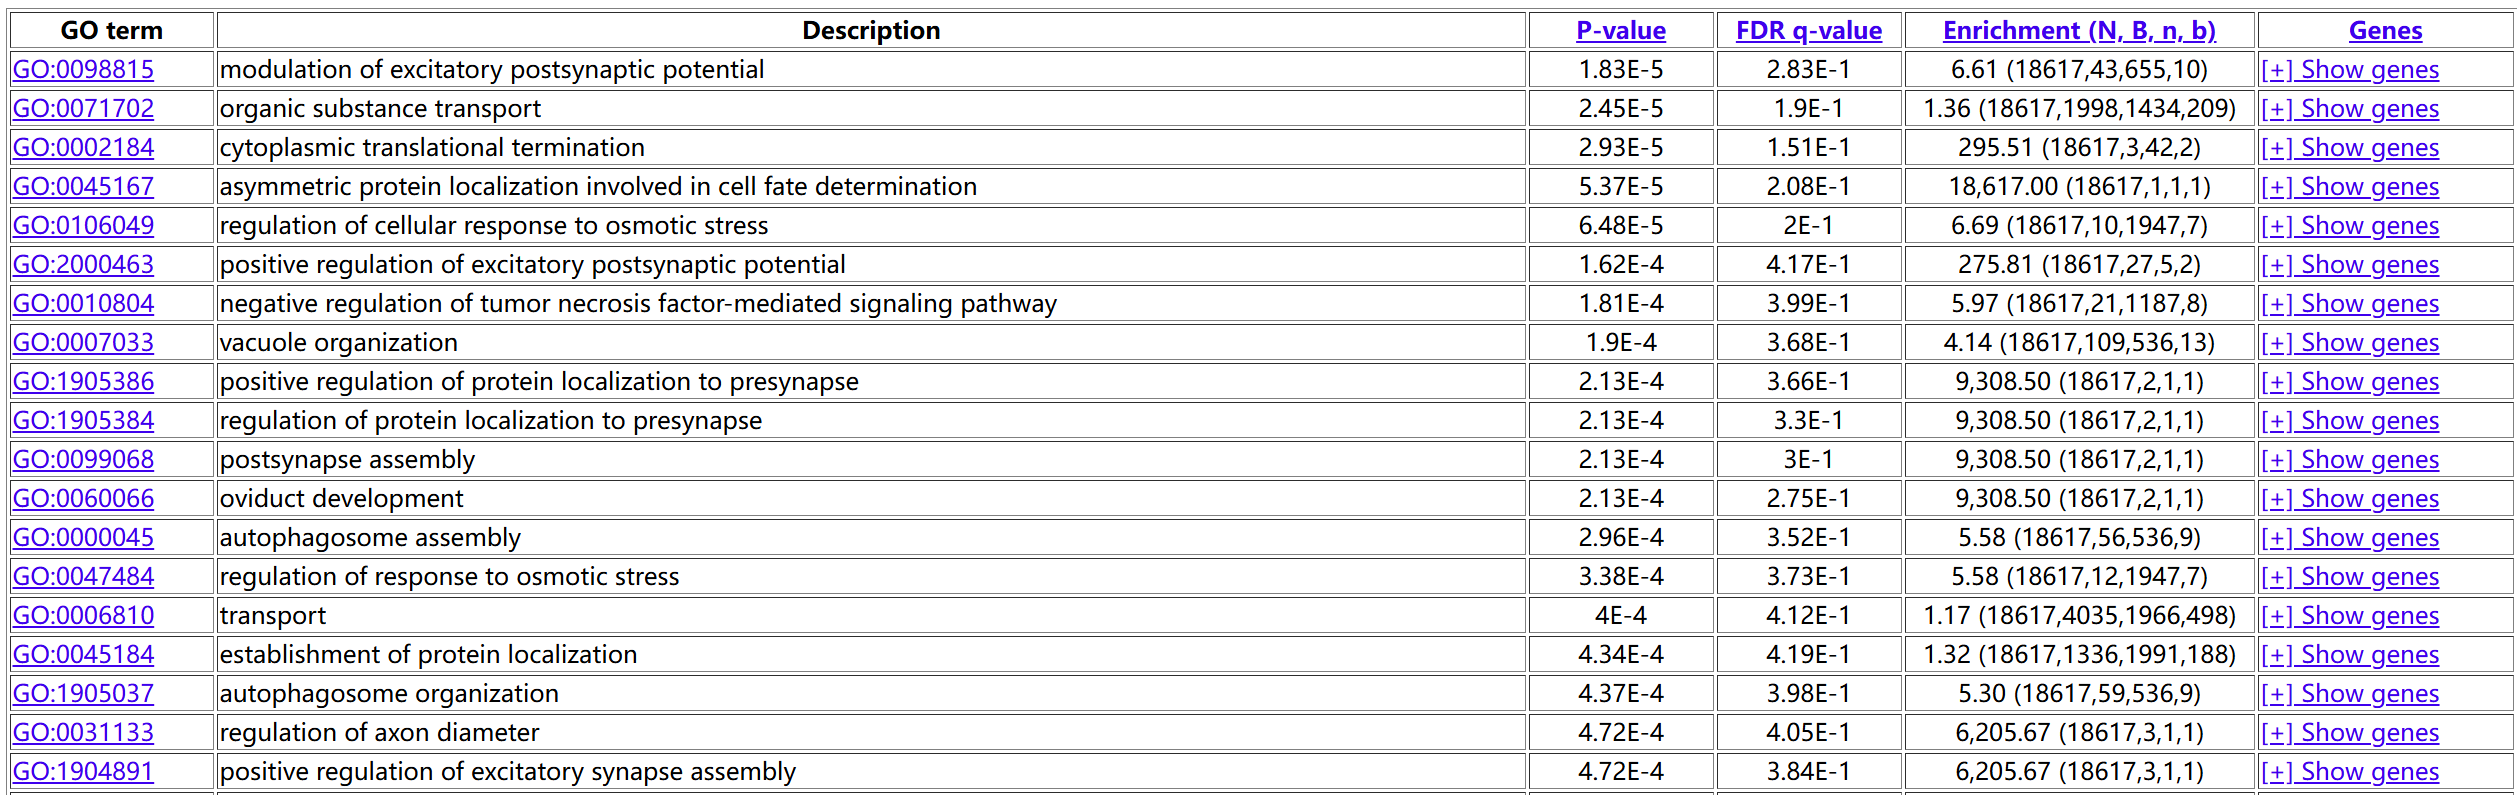

### Motif discovery
Motif analysis is the process of identifying short, recurring sequence patterns—known as motifs—in DNA (or RNA) that are recognized by regulatory proteins such as transcription factors (TFs). In the context of functional genomics, motif analysis helps link gene expression patterns to regulatory mechanisms. 

Up-regulated gene list is then run in iRegulon for `epiblast (EPI)`

In the figure below, we can see `ZBTB33` associates with many target genes in  `epiblast (EPI)`. The green node in the center stands for `ZBTB33`, which links to the surrounding pink nodes of the target genes. the `ZBTB33` regulon points to genes potentially regulated by a transcription factor that bridges DNA methylation status and signal-dependent gene regulation.

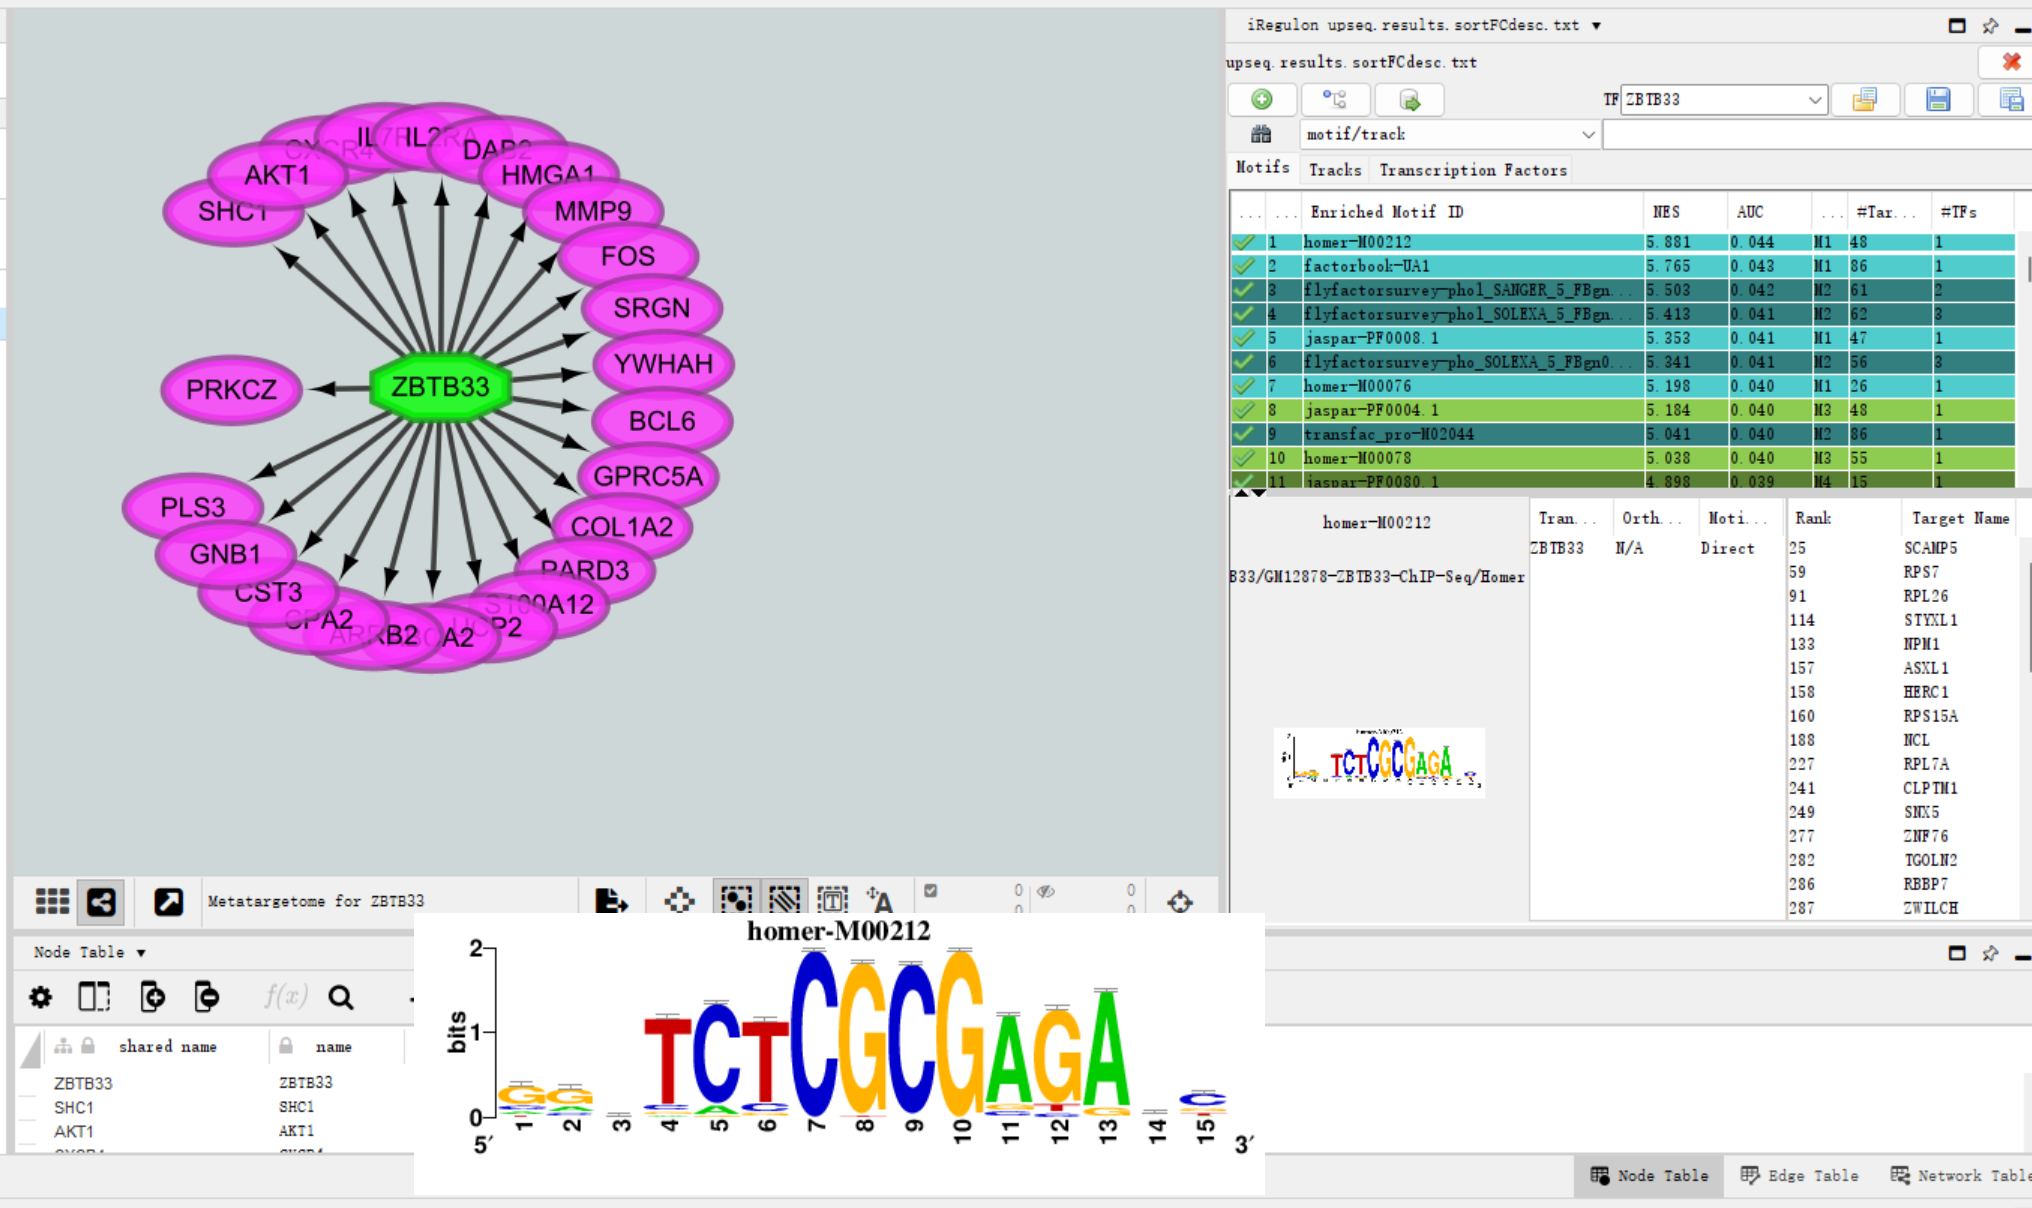

## Conclusion

In summary, scRNA-seq analysis encompasses data preprocessing, clustering, cell-type identification, and advanced downstream methods like functional analysis. It offers insights into embryo development in early stage and make significant in selection for implantation, potentially reducing failed implantation rates. 